# Control Systems 
## Samples 
### Markus Buchholz
<a href="mailto:markus.buchholz@canrig.com" style="text-align:center">markus.buchholz@canrig.com</a><br>

In [1]:
#start 1 order
#https://nbviewer.jupyter.org/github/OpenChemE/CHBE356/blob/master/Notebooks/3.%20Feedback%20Control/Control%20Actions%20and%20Plant%20Response%20Animation.ipynb
#response 2 order
#https://nbviewer.jupyter.org/github/DocVaughan/MCHE485---Mechanical-Vibrations/blob/Spring2019/Jupyter%20Notebooks/Mass%20Spring%20Damper%20-%20Direct%20Force.ipynb

#THIS
#https://nbviewer.jupyter.org/github/DocVaughan/MCHE474---Control-Systems/blob/master/Jupyter%20Notebooks/MCHE474%20-%20Control%20Systems%20Library%20Overview.ipynb

#BODE 2 order
#https://nbviewer.jupyter.org/github/DocVaughan/MCHE474---Control-Systems/blob/master/Jupyter%20Notebooks/MCHE474%20-%20Bode%20Plot%20Basics.ipynb
#https://github.com/python-control/python-control/blob/master/examples/bode-and-nyquist-plots.ipynb
    
#DC MOTOR NYQUIST
#https://nbviewer.jupyter.org/github/DocVaughan/MCHE474---Control-Systems/blob/master/Jupyter%20Notebooks/MCHE474%20-%20DC%20Motor%20PD%20Controller%20Design.ipynb

#NYQUIST

#https://nbviewer.jupyter.org/github/OpenChemE/CHBE356/blob/master/Notebooks/4.%20Stability%20Analysis/Nyquist%20Stability.ipynb
#http://blog.codelv.com/2013/02/control-systems-in-python-part-1.html

# OPEN LOOP
## Simulating a plant with time-dependent control actions

In [2]:
import control
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline

In [3]:
G_s = control.tf([1.5],[1,0.5,1])
G_s


      1.5
---------------
s^2 + 0.5 s + 1

## STEP RESPONSE

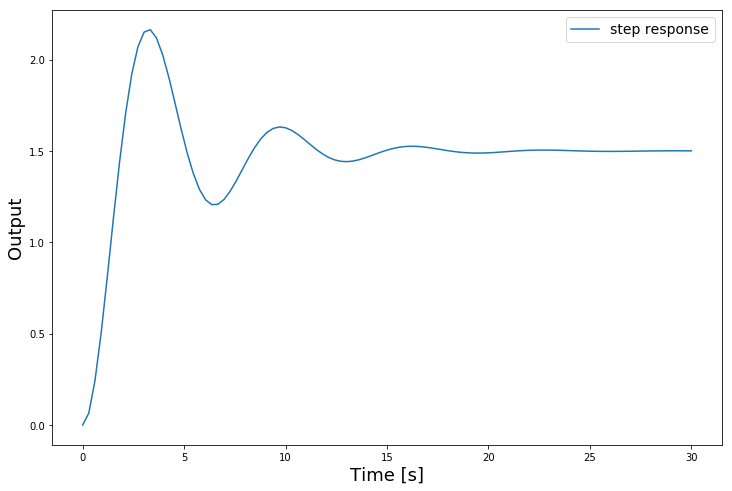

In [4]:
# Generate a step response
T = np.linspace(0,30,100)
t, yout = control.step_response(G_s,T)

# Plot
plt.figure(figsize=(12,8))


plt.plot(t,yout)
plt.xlabel('Time [s]', fontsize=18)
plt.ylabel('Output', fontsize=18)
plt.legend(['step response'], loc='upper right', fontsize=14)

# Output with control actions: FORCE RESPONSE

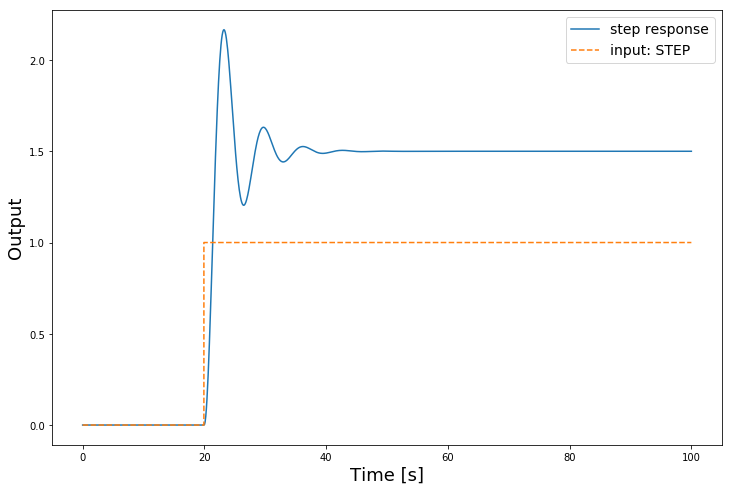

In [5]:
# Generate a step response
T = np.linspace(0,100,1000)


# Our input is all zero, until t=20
U = np.ones(len(T))
U[:200] = 0

t, yout, _ = control.forced_response(G_s, T, U)

# Plot
plt.figure(figsize=(12,8))

plt.plot(t,yout)
plt.step(t,U, linestyle='--') # We'll use `step` to create a staircase plot for the control actions
plt.xlabel('Time [s]', fontsize=18)
plt.ylabel('Output', fontsize=18)
plt.legend(['step response', 'input: STEP'], loc='upper right', fontsize=14)

# Output with control actions: IMPULSE RESPONSE

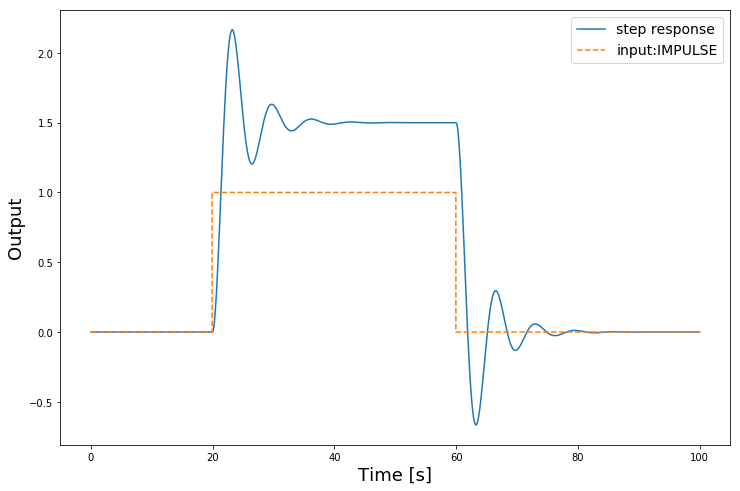

In [6]:
# Generate a step response
T = np.linspace(0,100,1000)

# Our input is one between t=20 and t=60
U = np.zeros(len(T))
U[200:600] = 1

t, yout, _ = control.forced_response(G_s, T, U)

# Plot
plt.figure(figsize=(12,8))
plt.plot(t,yout)
plt.step(t,U, linestyle='--')
plt.xlabel('Time [s]', fontsize=18)
plt.ylabel('Output', fontsize=18)
plt.legend(['step response', 'input:IMPULSE'], loc='upper right', fontsize=14)

# *** FIRST ORDER SYSTEM*** 



The general form of the first-order differential equation is as follows:

<span style="font-size:2em;">$ \quad \dot{y} + ay = bu $</span>


The form of a first-order transfer function is:

<span style="font-size:2em;">$ \quad G(s) = \frac{X(s)}{F(s)} = \frac{b}{\tau s + a} $</span>


### DC Gain

The DC gain, $\frac{b}{a}$, is the ratio of the magnitude of the steady-state step response to the magnitude of the step input. For stable transfer functions, the Final Value Theorem demonstrates that the DC gain is the value of the transfer function evaluated at $s$ = 0. 

### Time Constant

The time constant of a first-order system is $T_c = \tau = 1/a$ which is equal to the time it takes for the system's response to reach 63% of its steady-state value for a step input (from zero initial conditions) or to decrease to 37% of the initial value for a system's free response. 

### Poles/Zeros

First-order systems have a single real pole, in this case at $s = -a$. Therefore, the system is stable if $a$ is positive and unstable if $a$ is negative. Standard first-order system have no zeros.



In [7]:
b=5
T = 10 #tau
a = 1
G_s = control.tf([b],[T,a])
sys  = G_s
G_s


    5
--------
10 s + 1

## FIRST ORDER SYSTEM STEP RESPONSE 

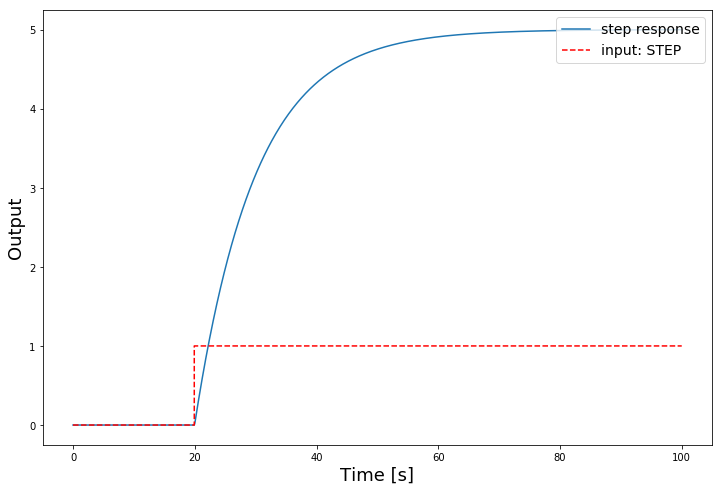

In [8]:
# Generate a step response
T = np.linspace(0,100,1000)


# Our input is all zero, until t=20
U = np.ones(len(T))
U[:200] = 0

t, yout, _ = control.forced_response(G_s, T, U)

# Plot
plt.figure(figsize=(12,8))

plt.plot(t,yout)
plt.step(t,U, linestyle='--',color="red" ) # We'll use `step` to create a staircase plot for the control actions
plt.xlabel('Time [s]', fontsize=18)
plt.ylabel('Output', fontsize=18)
plt.legend(['step response', 'input: STEP'], loc='upper right', fontsize=14)

## ANALYSIS OF THE SYSTEM  

## POLES

In [9]:
sys.pole()

array([-0.1])

## ZEROS

In [10]:
sys.zero()

array([], dtype=float64)

## POLES - ZEROS PLOT

<Figure size 864x576 with 0 Axes>

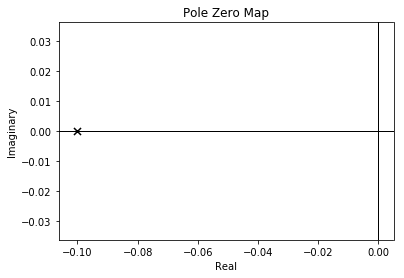

<Figure size 864x576 with 0 Axes>

In [11]:

poles, zeros = control.pzmap(sys, Plot=True)
plt.figure(figsize=(12,8))


## ROOT LOCUS

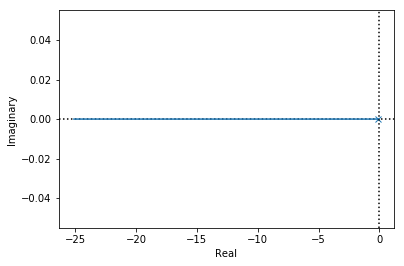

In [12]:
roots, gains = control.root_locus(sys, kvect = np.linspace(0,50,50001), Plot=True)

 ## BODE PLOT


Bode diagrams show the magnitude and phase of a system's frequency response, $G(j\omega)$, plotted with respect to frequency $\omega$.

In [13]:
b=5
T = 10 #tau
a = 1
num = [5]
den = [10, 1]
sys = control.tf([b],[T,a])
sys = control.tf(num, den)
sys



    5
--------
10 s + 1

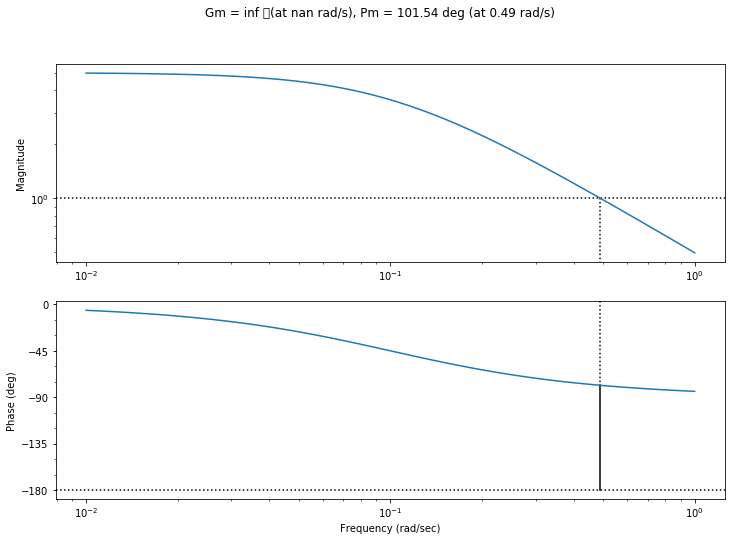

In [14]:
plt.figure(figsize=(12,8))
mag, phase, omega = control.bode_plot(sys, Hz=False, margins = True)

## NYQUIST PLOT

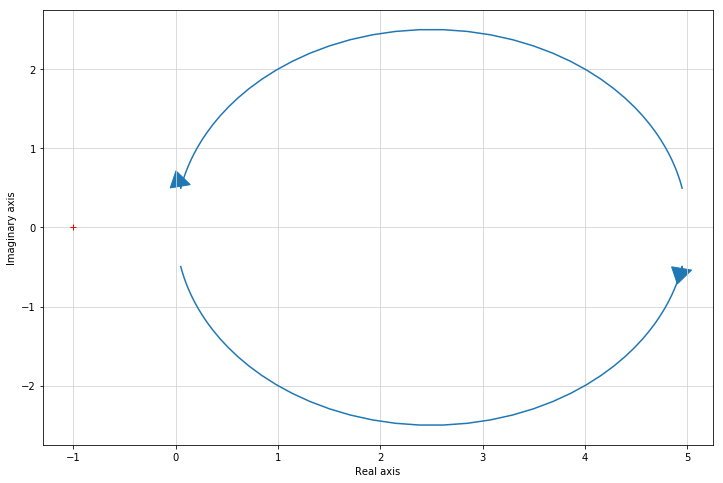

In [15]:
plt.figure(figsize=(12,8))
mag, phase, omega = control.nyquist_plot([sys])

In [16]:
# Grab all of the NumPy functions with namespace np
import numpy as np              

In [17]:
%matplotlib inline

# Import the plotting functions 
import matplotlib.pyplot as plt

In [18]:
import control # This will import the control library.  

# ***SECOND ORDER SYSTEM***
We'll start by looking at the system in Figure 1. It's a simple mass-spring-damper system, with mass $m$ connected to ground through a spring $k$ and damper $c$. There is also a input force, $f$, acting on the mass.

<p style="text-align:center">
	<img src="http://crawlab.org/shared/MassSpringDamper_DirectForce_Horiz.png" alt="Example Mass-spring-damper System" width=50%><br>
    <strong>Figure 1: Example Mass-spring-damper System</strong>
</p>
The equation of  motion of this system is:

<span style="font-size:2em;">$ \quad m \ddot{x} + c \dot{x} + kx = f $</span>

If we define $\omega_n$ to be the system's *natural frequency* and $\zeta$ as the system's *damping ratio*, we can rewrite this equation as:

<span style="font-size:2em;">$ \quad \ddot{x} + \frac{c}{m} \dot{x} + \frac{k}{m}x = \frac{f}{m} $</span>

Then,

<span style="font-size:2em;">$ \quad \ddot{x} + 2\zeta\omega_n \dot{x} + \omega_n^2 x = \frac{f}{m} $</span>

where
<span style="font-size:2em;">$ \quad \omega_n = \sqrt{\frac{k}{m}} $</span>

and 

The damping ratio $\zeta$ is a dimensionless quantity charaterizing the rate at which an oscillation in the system's response decays due to effects such as viscous friction or electrical resistance. 

<span style="font-size:2em;">$\zeta = \frac{b}{2 \sqrt{k m}}$</span>

Like the time-domain solution, we can also write this transfer function  (in s - domain) in terms of the natural frquency, $\omega_n$, and damping ratio, $\zeta$, of the system:

<span style="font-size:2em;">$ \quad G(s) = \frac{X(s)}{F(s)} = \frac{1/m}{s^2 + 2\zeta\omega_n s + \omega_n^2} $</span>

<span style="font-size:2em;">$ \quad G(s) = \frac{X(s)}{F(s)} = \frac{\omega_n^2}{s^2 + 2\zeta\omega_n s + \omega_n^2} $</span>

Let's use this second form.  For the parameters we selected above, it is:

<span style="font-size:2em;">$ \quad G(s) = \frac{X(s)}{F(s)} = \frac{1}{s^2 + s + 1} $</span>

We'll first define an array, which we'll call `num` that contains the numerator value. Since it only has one value, the command will be of the form:

<span style="font-size:2em;">$ \quad   num = \frac{1}{m} $</span>

To define the denominator, we need to create an array where the element represents the power of `s` for the constant there. In this case:


<span style="font-size:2em;">$ \quad    den = [1, 2 * zeta * w_n, w_n**2]$</span>

To check this, work from the "right" side of the definition. `w_n**2` is $\omega_n^2$, which is mulitplied by $s^0$. The next element is `2 * zeta * w_n`, which is the $2\zeta\omega_n$ term and given its position in the first indexed element of the array is multiplied by $s^1$. This continues for all similar definitions.

**Note:**



## Working with Transfer Functions

In [19]:
# Define the numerator and denominator of the transfer function
#G = 50/(s^3 + 9*s^2 + 30*s +40);
num = [50]
den = [3, 9, 30, 40]

Now, that these are defined, we can pass them to the `tf` function of the library. Remember that since `tf` is a function in the `control` module, we need to use `control.tf()` to call it. We'll assign the variable `sys` to hold transfer function returned. 

In [20]:
# Define the transfer function form of the system defined by num and den
sys = control.tf(num, den)

We can check that the transfer function is defined correctly by printing `sys`.

In [21]:
print(sys)


            50
-------------------------
3 s^3 + 9 s^2 + 30 s + 40



## ANALYSIS OF THE SYSTEM 


## SECOND ORDER SYSTEM STEP RESPONSE 

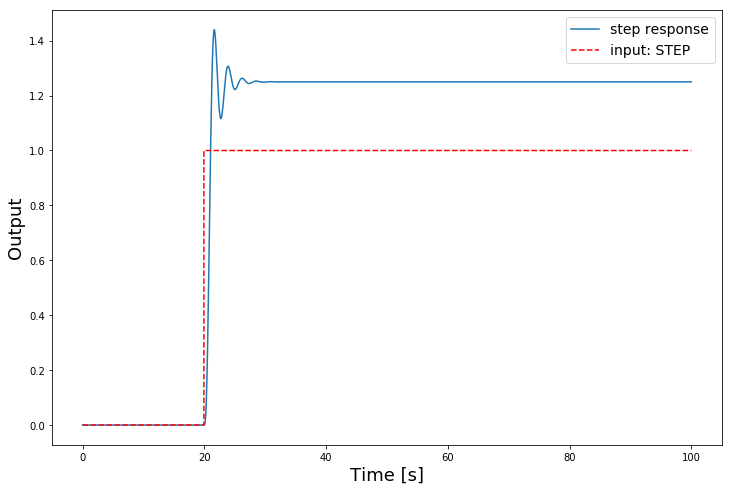

In [22]:
# Generate a step response
T = np.linspace(0,100,1000)


# Our input is all zero, until t=20
U = np.ones(len(T))
U[:200] = 0

t, yout, _ = control.forced_response(sys, T, U)

# Plot
plt.figure(figsize=(12,8))

plt.plot(t,yout)
plt.step(t,U, linestyle='--',color="red" ) # We'll use `step` to create a staircase plot for the control actions
plt.xlabel('Time [s]', fontsize=18)
plt.ylabel('Output', fontsize=18)
plt.legend(['step response', 'input: STEP'], loc='upper right', fontsize=14)

## POLES AND ZEROS

### POLES

In [23]:
sys.pole()

array([-0.64468155+2.71638613j, -0.64468155-2.71638613j,
       -1.7106369 +0.j        ])

### ZEROS

In [24]:
sys.zero()

array([], dtype=float64)

### PLOT

<Figure size 864x576 with 0 Axes>

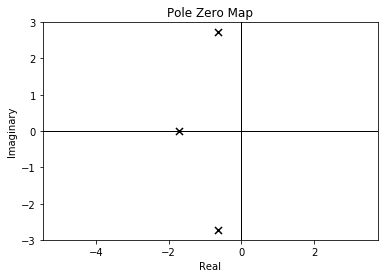

<Figure size 864x576 with 0 Axes>

In [25]:
poles, zeros = control.pzmap(sys, Plot=True)
plt.figure(figsize=(12,8))

### ROOT LOCUS

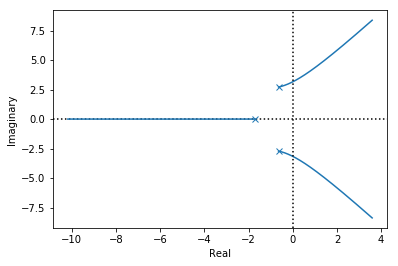

In [26]:
roots, gains = control.root_locus(sys, kvect = np.linspace(0,50,50001), Plot=True)

### BODE PLOT

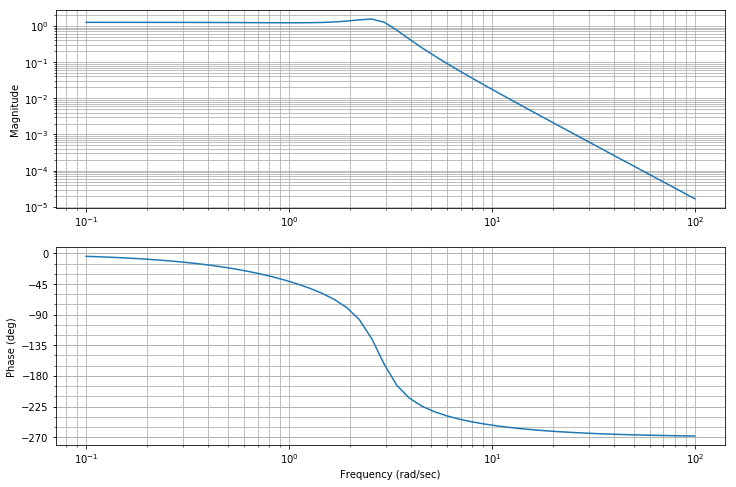

In [27]:
plt.figure(figsize=(12,8))
mag, phase, omega = control.bode_plot(sys, Hz=False)

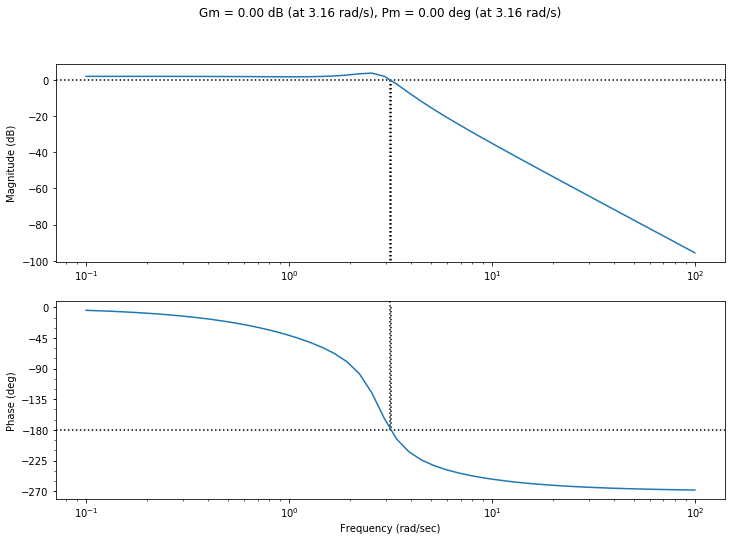

In [28]:
plt.figure(figsize=(12,8))
mag, phase, omega = control.bode_plot(sys, Hz=False,dB=True, margins = True)

In [29]:
num = [50]
den = [3, 9, 30, 40]
sys = control.tf(num, den)
sys


            50
-------------------------
3 s^3 + 9 s^2 + 30 s + 40

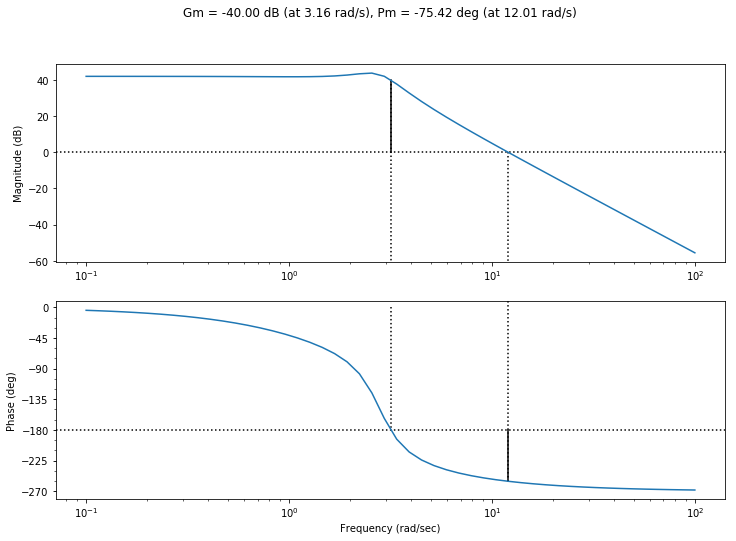

In [30]:
plt.figure(figsize=(12,8))
mag, phase, omega = control.bode_plot(sys*100, Hz=False,dB=True, margins = True)
#100=40dB

### NYQUIST PLOT

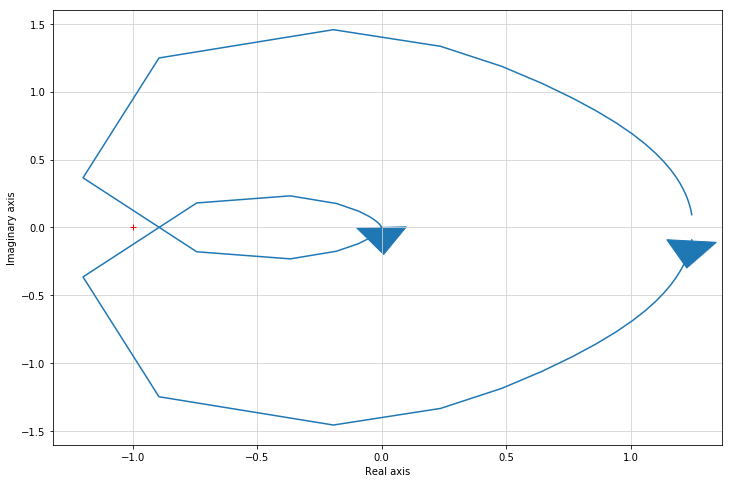

In [31]:
plt.figure(figsize=(12,8))
mag, phase, omega = control.nyquist_plot([sys])

# BODE PLOT Introduction

### FORCE RESPONSE

In [32]:
num = [2, 1]
den = [1, 0]

In [33]:
# Define the transfer function form of the system defined by num and den
sys = control.tf(num, den)
sys


2 s + 1
-------
   s

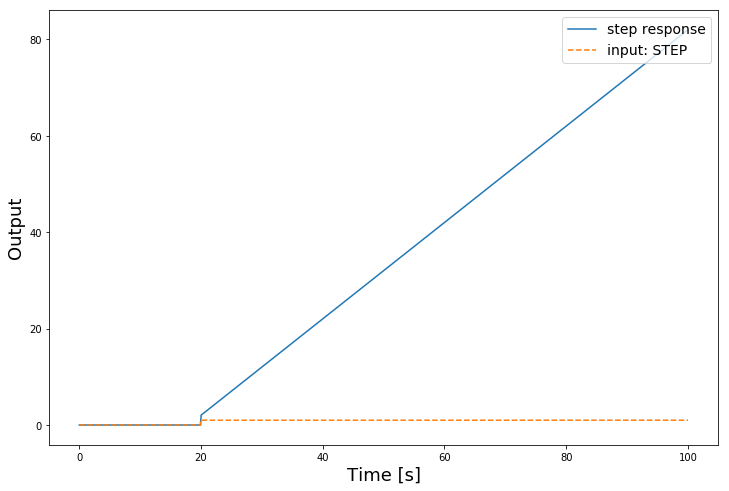

In [34]:
# Generate a step response
T = np.linspace(0,100,1000)


# Our input is all zero, until t=20
U = np.ones(len(T))
U[:200] = 0

t, yout, _ = control.forced_response(sys, T, U)

# Plot
plt.figure(figsize=(12,8))

plt.plot(t,yout)
plt.step(t,U, linestyle='--') # We'll use `step` to create a staircase plot for the control actions
plt.xlabel('Time [s]', fontsize=18)
plt.ylabel('Output', fontsize=18)
plt.legend(['step response', 'input: STEP'], loc='upper right', fontsize=14)

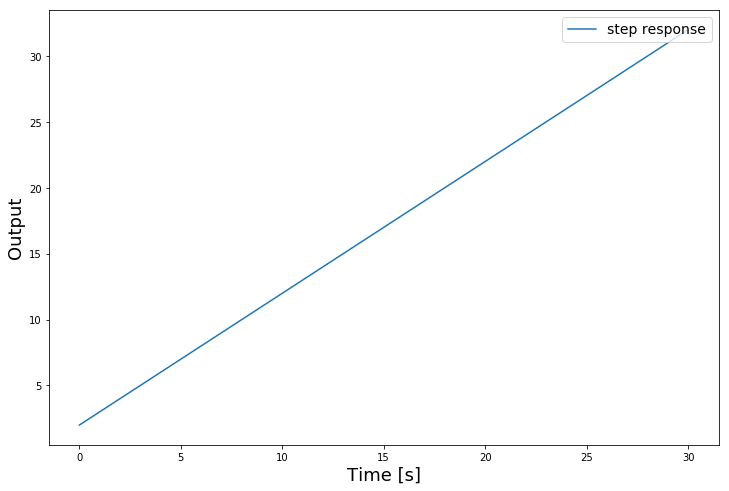

In [35]:
# Generate a step response
T = np.linspace(0,30,100)
t, yout = control.step_response(sys,T)

# Plot
plt.figure(figsize=(12,8))


plt.plot(t,yout)
plt.xlabel('Time [s]', fontsize=18)
plt.ylabel('Output', fontsize=18)
plt.legend(['step response'], loc='upper right', fontsize=14)

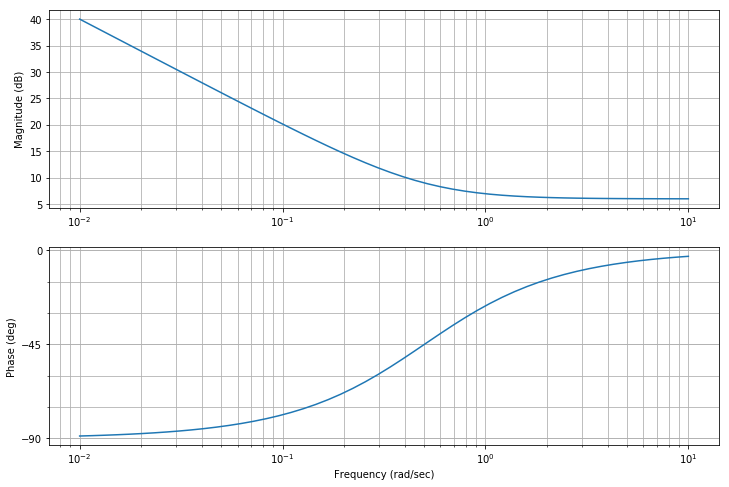

In [36]:
plt.figure(figsize=(12,8))
mag, phase, omega = control.bode_plot(sys, dB= True, Hz=False)

## GAIN - K - BODE PLOT Introduction

In [37]:
num = [2]
den = [1]
sys = control.tf(num, den)
sys


2
-
1

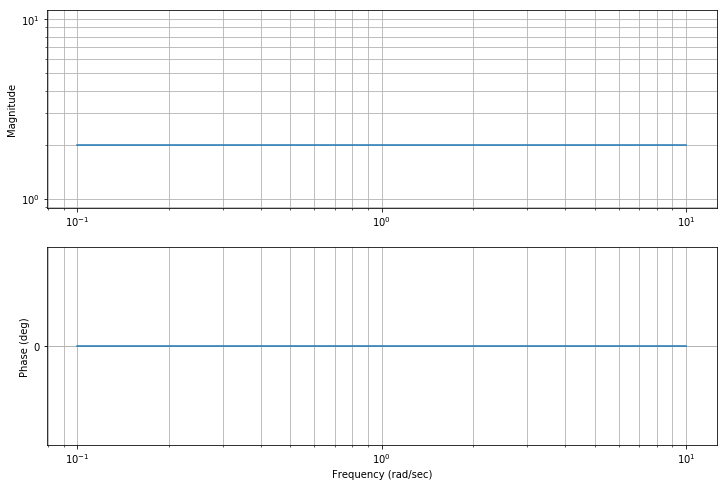

In [38]:
plt.figure(figsize=(12,8))
mag, phase, omega = control.bode_plot(sys, Hz=False)

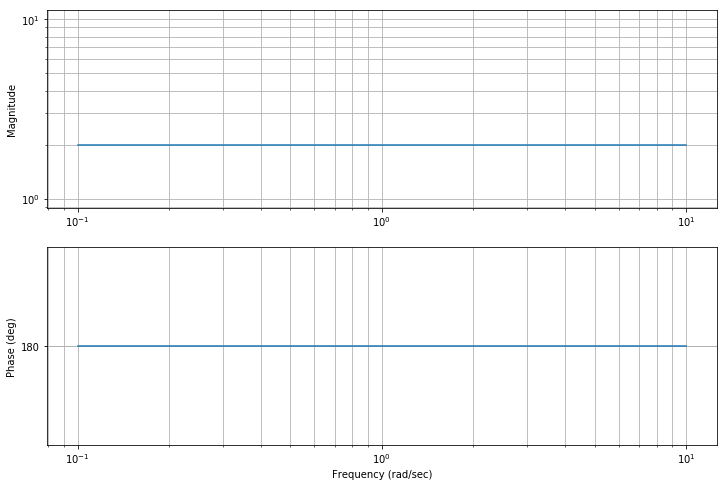

In [39]:
plt.figure(figsize=(12,8))
mag, phase, omega = control.bode_plot(-sys, Hz=False)

## INTEGRAL - 1/s - BODE PLOT Introduction

In [40]:
num = [1]
den = [1, 0]
sys = control.tf(num, den)
sys


1
-
s

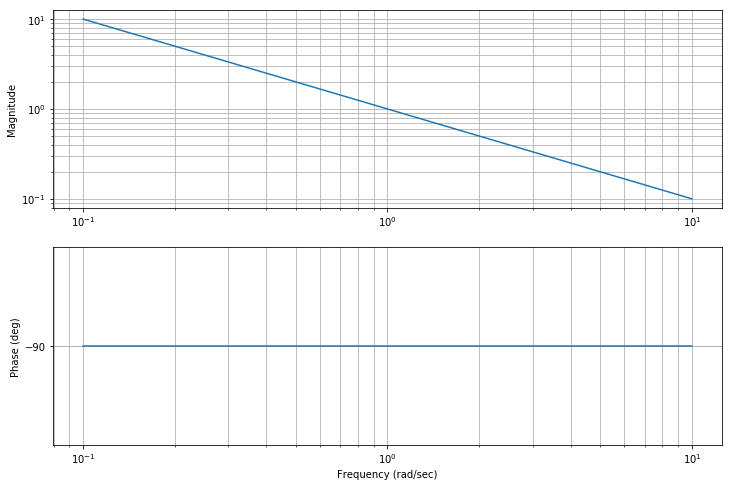

In [41]:
plt.figure(figsize=(12,8))
mag, phase, omega = control.bode_plot(sys, Hz=False)

## Derivative - s -   PLOT Introduction

In [42]:
num = [1,0]
den = [1]
sys = control.tf(num, den)
sys


s
-
1

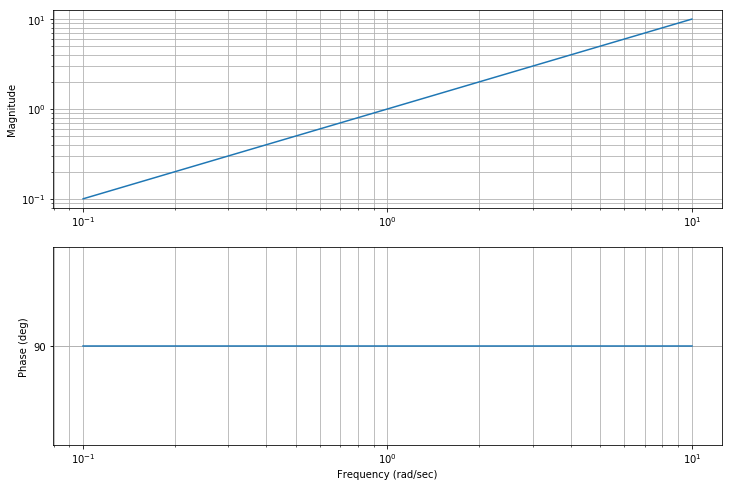

In [43]:
plt.figure(figsize=(12,8))
mag, phase, omega = control.bode_plot(sys, Hz=False)

## TESTS
### Multiplication in s-domain = add in log

In [44]:
num1 = [3]
den1 = [1, 0]
sys1 = control.tf(num1, den1)
num2 = [4,3,2,1]
den2 = [1,0,0]
sys2 = control.tf(num2, den2)
print(sys1)
print(sys2)


3
-
s


4 s^3 + 3 s^2 + 2 s + 1
-----------------------
          s^2



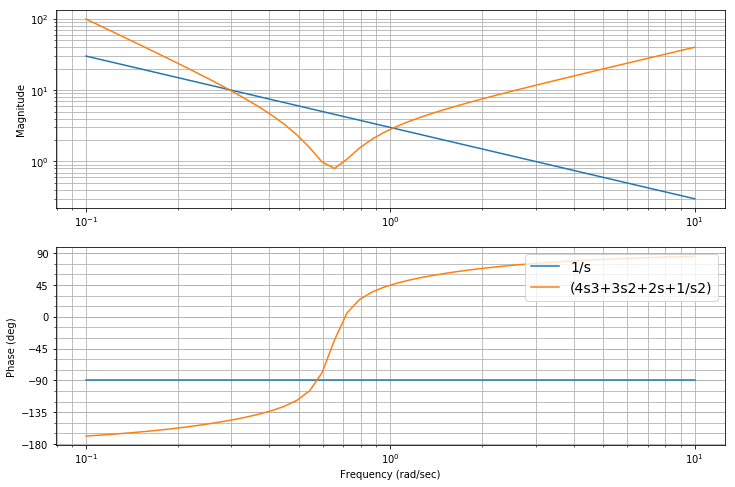

In [45]:
plt.figure(figsize=(12,8))
plt.legend(['1/s', '1/s*s*s'], loc='upper right', fontsize=14)
mag, phase, omega = control.bode_plot(sys1, Hz=False)
mag, phase, omega = control.bode_plot(sys2, Hz=False)
plt.legend(['1/s', '(4s3+3s2+2s+1/s2)'], loc='upper right', fontsize=14)

In [46]:
num0= [3]
den0= [1]
sys0= control.tf(num0,den0)
num1 = [1]
den1 = [1, 0]
sys1 = control.tf(num1, den1)
num2 = [1]
den2 = [1, 0,0]
sys2 = control.tf(num2, den2)
num3 = [3]
den3 =[1, 0,0]
sys3= control.tf(num3,den3)
print(sys0)
print(sys1)
print(sys2)
print(sys3)


3
-
1


1
-
s


 1
---
s^2


 3
---
s^2



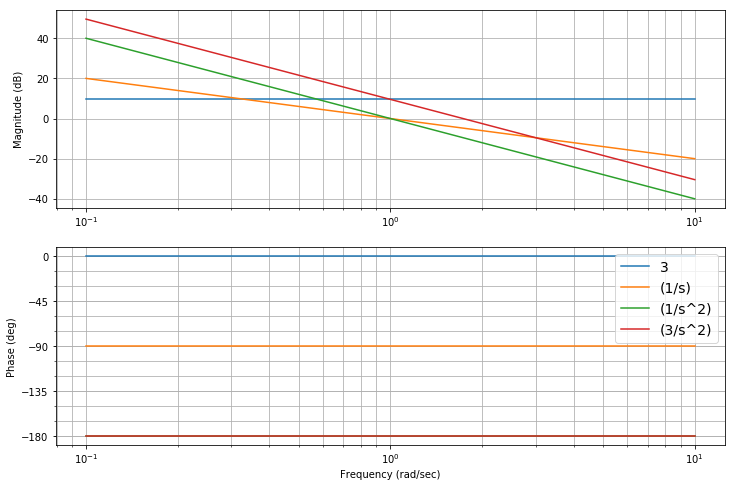

In [47]:
plt.figure(figsize=(12,8))
mag, phase, omega = control.bode_plot(sys0, Hz=False, dB=True)
mag, phase, omega = control.bode_plot(sys1, Hz=False, dB=True)
mag, phase, omega = control.bode_plot(sys2, Hz=False, dB=True)
mag, phase, omega = control.bode_plot(sys3, Hz=False, dB=True)
plt.legend(['3', '(1/s)','(1/s^2)','(3/s^2)'], loc='upper right', fontsize=14)

In [48]:
import numpy as np 
  
arr1 = [0] 
arr2 = [0] 
  
ans = np.arctan2(arr2, arr1) * 180 / np.pi 
  
print ("x-coordinates : ", arr1) 
print ("y-coordinates : ", arr2) 
  
print ("\narctan2 values : \n", ans) 

x-coordinates :  [0]
y-coordinates :  [0]

arctan2 values : 
 [0.]


In [49]:
num = [1, 3, 5, 7]
den = [2, 4, 6, 8, 2]
sys = control.tf(num, den)
sys


#feed1 = control.feedback(sys1,1)
#feed2 = control.feedback(sys2,-1)
#print(feed1)
#print(feed2)



     s^3 + 3 s^2 + 5 s + 7
-------------------------------
2 s^4 + 4 s^3 + 6 s^2 + 8 s + 2

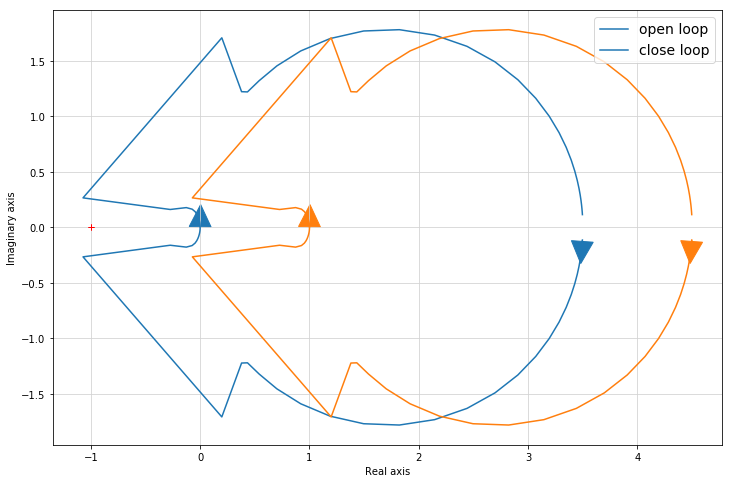

In [50]:
plt.figure(figsize=(12,8))
#plt.legend(['open loop', 'close loop'], loc='upper right', fontsize=14)
mag, phase, omega = control.nyquist_plot([sys])
plt.legend(['open loop', 'close loop'], loc='upper right', fontsize=14)
mag, phase, omega = control.nyquist_plot([sys + 1])


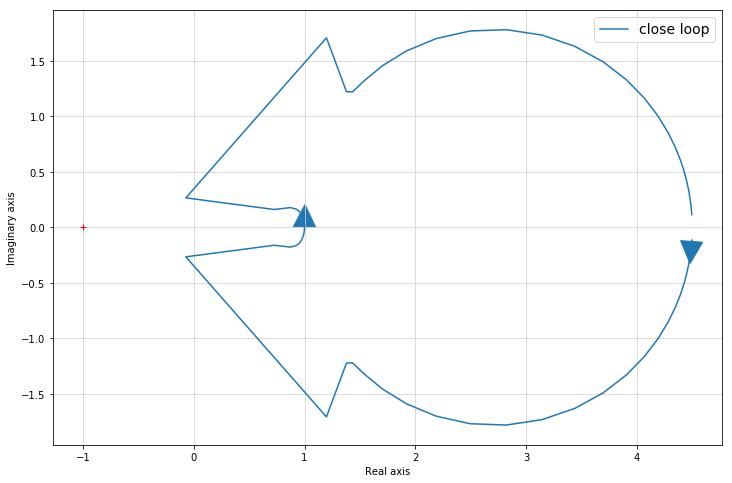

In [51]:
plt.figure(figsize=(12,8))
mag, phase, omega = control.nyquist_plot([sys + 1])
plt.legend(['close loop'], loc='upper right', fontsize=14)

<Figure size 864x576 with 0 Axes>

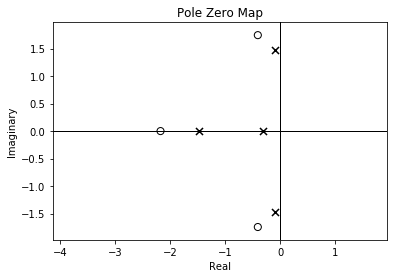

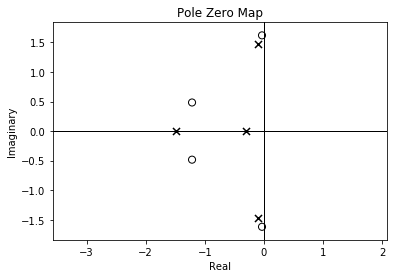

<Figure size 864x576 with 0 Axes>

In [52]:
poles, zeros = control.pzmap(sys, Plot=True)
poles, zeros = control.pzmap(sys+1, Plot=True)
plt.figure(figsize=(12,8))

# Open/Closed-Loop Performance from Bode Plots and Nyquist

### Open

In [53]:
num = [1.3,2.6]
den = [1, 1, 6 , 1]
sys = control.tf(num, den)
sys





    1.3 s + 2.6
-------------------
s^3 + s^2 + 6 s + 1

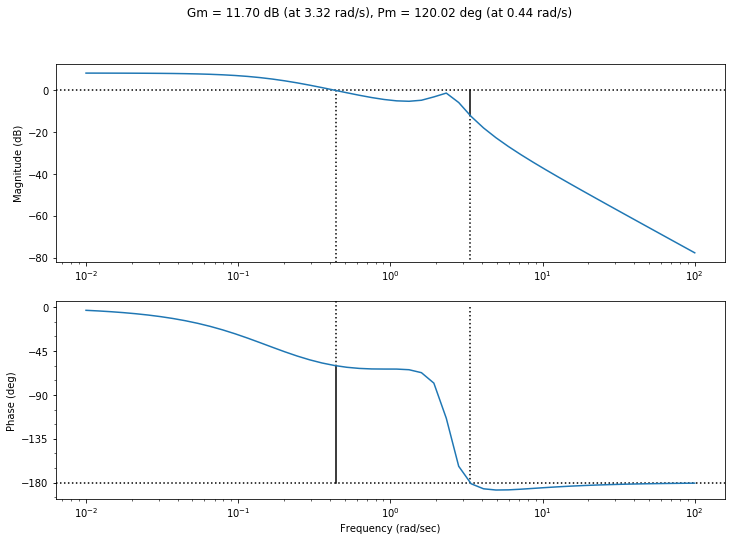

In [54]:
plt.figure(figsize=(12,8))
mag, phase, omega = control.bode_plot(sys, Hz=False, dB=True, margins = True)
# 10^0 - 0.32 = 0.58=>3.85 dB

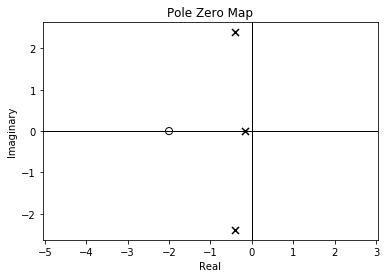

In [55]:
poles, zeros = control.pzmap(sys, Plot=True)

### WE GO ALMOST TO UNSTABLE (for open) => WE DO NOT MARGIN ALMOST AT ALL!!!

In [56]:
num = [1.3,2.6]
den = [1, 1, 3 , 1] #  6->3
sys = control.tf(num, den)
sys


    1.3 s + 2.6
-------------------
s^3 + s^2 + 3 s + 1

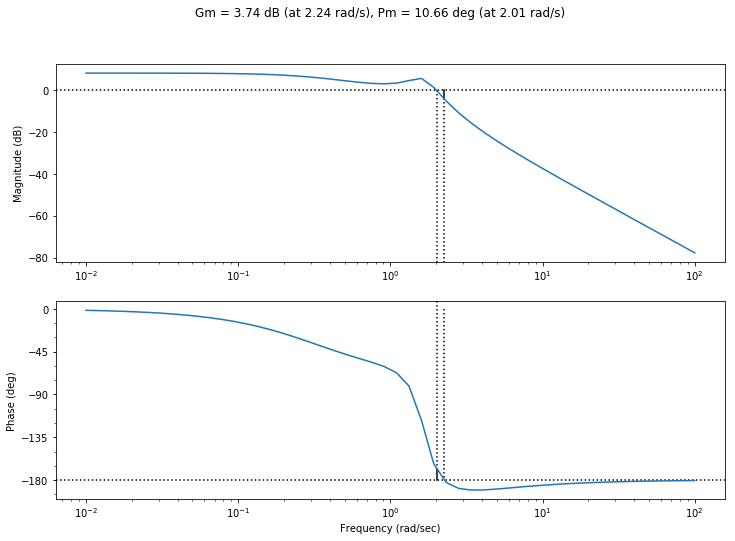

In [57]:
plt.figure(figsize=(12,8))
mag, phase, omega = control.bode_plot(sys, Hz=False,dB= True, margins = True)

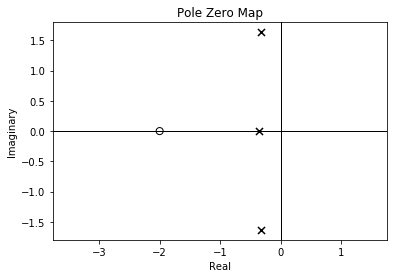

In [58]:
poles, zeros = control.pzmap(sys, Plot=True)

In [59]:
num = [13,2.6]
den = [1, 1, 6 , 1] #  
sys = control.tf(num, den)
sys


    13 s + 2.6
-------------------
s^3 + s^2 + 6 s + 1

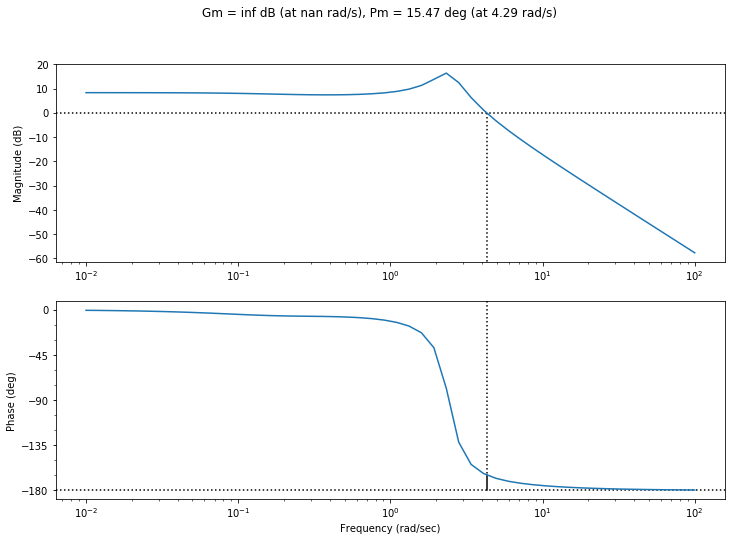

In [60]:
plt.figure(figsize=(12,8))
mag, phase, omega = control.bode_plot(sys, Hz=False, margins = True, dB=True)

# NYQUIST AND BODE STABILITY

In [61]:
num = [6]
den = [1, 4, 3]   
sys = control.tf(num, den)
sys


      6
-------------
s^2 + 4 s + 3

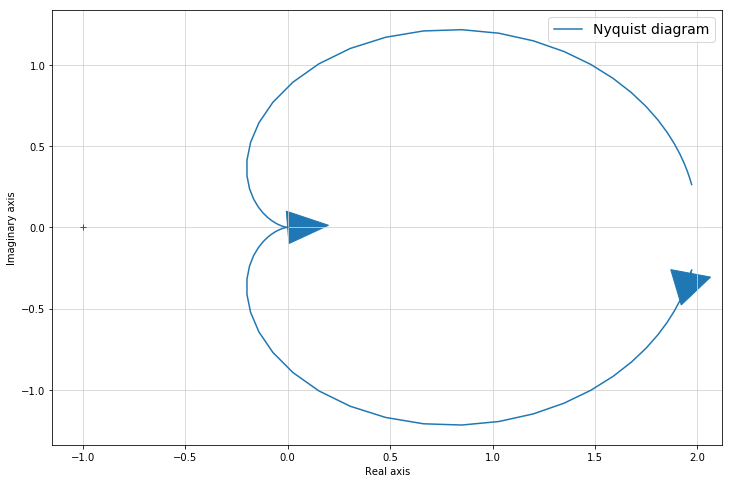

In [62]:
plt.figure(figsize=(12,8))
mag, phase, omega = control.nyquist_plot([sys])
plt.legend(['Nyquist diagram'], loc='upper right', fontsize=14)

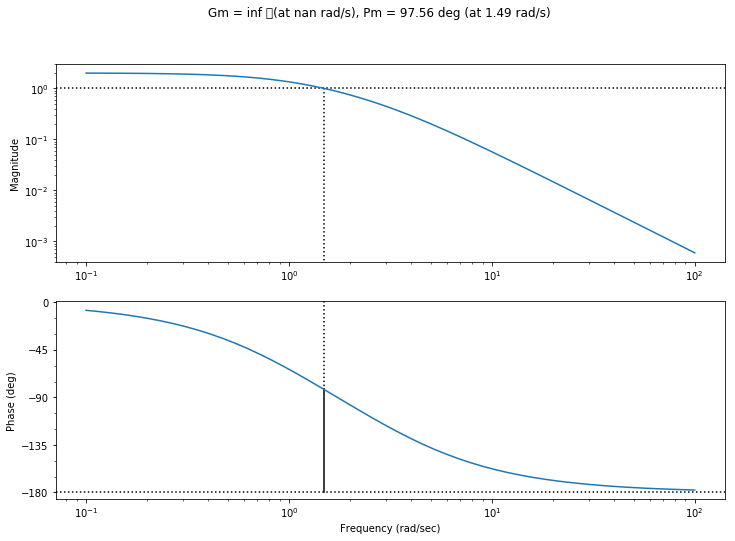

In [63]:
plt.figure(figsize=(12,8))
mag, phase, omega = control.bode_plot(sys, Hz=False, margins = True)

## SYSTEM UNSTABLE

In [64]:
num = [500]
den = [1, 5, 54,50 ] #  6->3
sys = control.tf(num, den)
sys

#num = [1.3,2.6]
#den = [-1, -1, -6,-1 ] #  6->3
#sys = control.tf(num, den)
#sys


          500
-----------------------
s^3 + 5 s^2 + 54 s + 50

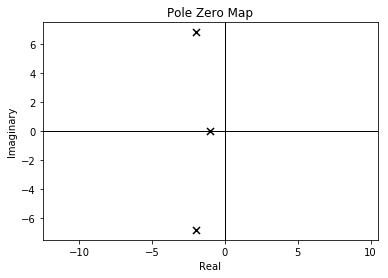

In [65]:
poles, zeros = control.pzmap(sys, Plot=True)

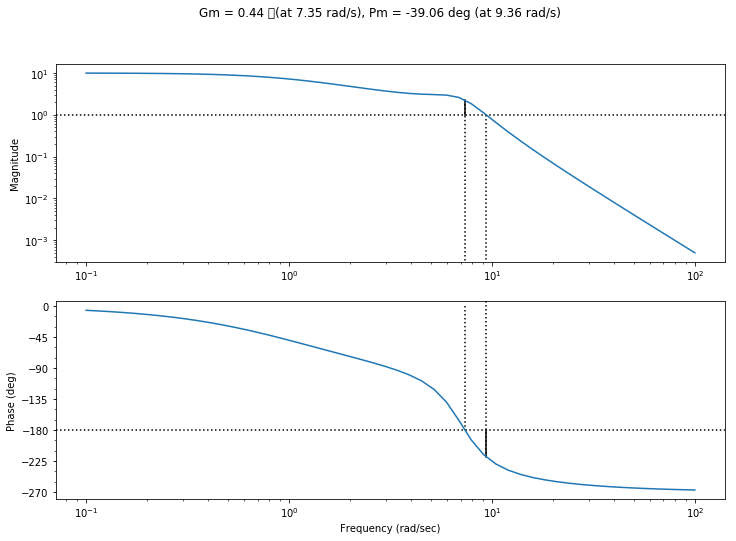

In [66]:
plt.figure(figsize=(12,8))
mag, phase, omega = control.bode_plot(sys, Hz=False, margins = True)

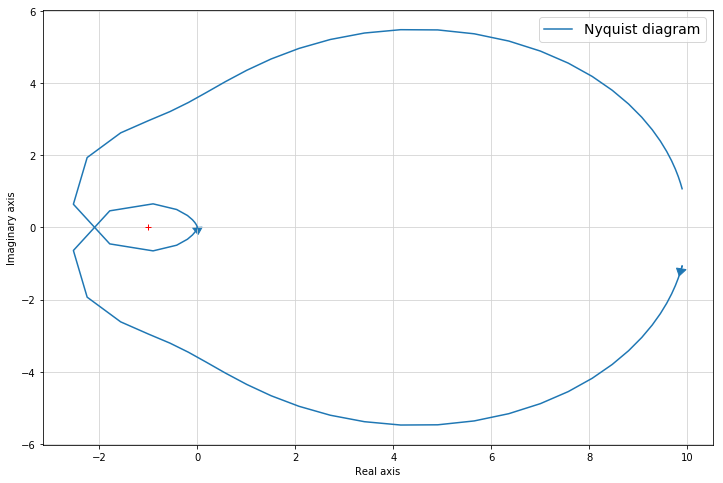

In [67]:
plt.figure(figsize=(12,8))
mag, phase, omega = control.nyquist_plot([sys])
plt.legend(['Nyquist diagram'], loc='upper right', fontsize=14)

# Closed-Loop Stability from the Nyquist Diagram

In [68]:
num = [1,10,24]
den = [1, -8, 15]
sys = control.tf(num, den)
sys


s^2 + 10 s + 24
---------------
s^2 - 8 s + 15

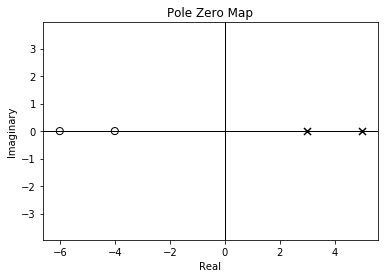

In [69]:
poles, zeros = control.pzmap(sys, Plot=True)

In [70]:
poles

array([5., 3.])

Text(0.5, 1.0, 'Close loop system STABLE: 2 poles = 2 CCW ')

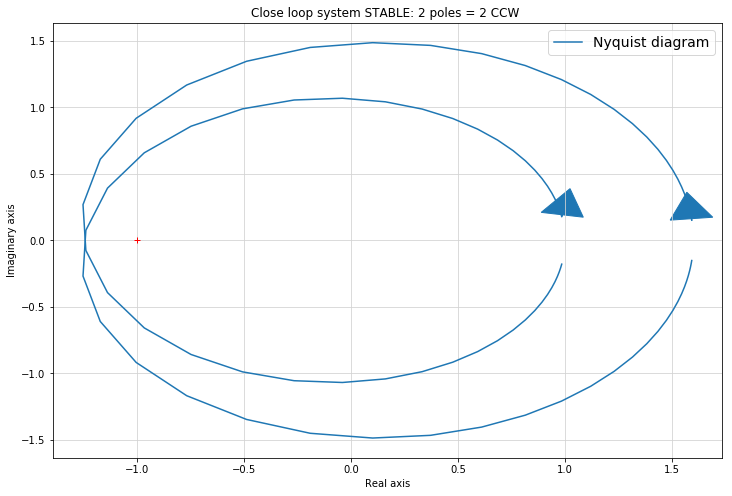

In [71]:
plt.figure(figsize=(12,8))
mag, phase, omega = control.nyquist_plot([sys])
plt.legend(['Nyquist diagram'], loc='upper right', fontsize=14)
plt.title('Close loop system STABLE: 2 poles = 2 CCW ')

In [72]:
num = [10,100,240]
den = [1, -8, 15]
sys = control.tf(num, den)
sys


10 s^2 + 100 s + 240
--------------------
   s^2 - 8 s + 15

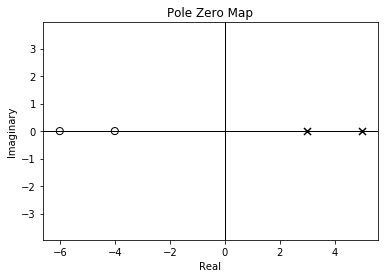

In [73]:
poles, zeros = control.pzmap(sys, Plot=True)

Text(0.5, 1.0, 'Close loop system STABLE: 2 poles = 2 CCW ')

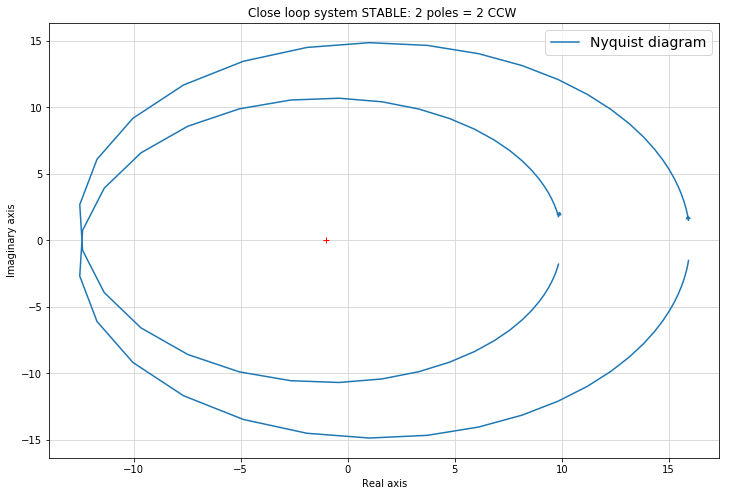

In [74]:
plt.figure(figsize=(12,8))
mag, phase, omega = control.nyquist_plot([sys])
plt.legend(['Nyquist diagram'], loc='upper right', fontsize=14)
plt.title('Close loop system STABLE: 2 poles = 2 CCW ')

In [75]:
num = [0.5,5,12]
den = [1, -8, 15]
sys = control.tf(num, den)
sys


0.5 s^2 + 5 s + 12
------------------
  s^2 - 8 s + 15

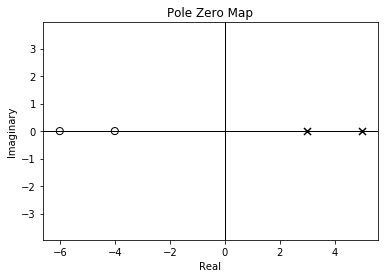

In [76]:
poles, zeros = control.pzmap(sys, Plot=True)

Text(0.5, 1.0, 'Close loop system UNSTABLE !!!: 2 poles but NO CCW ')

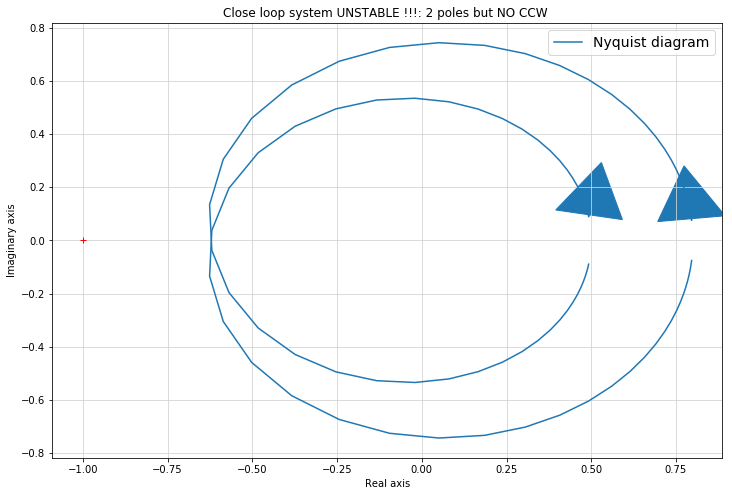

In [77]:
plt.figure(figsize=(12,8))
mag, phase, omega = control.nyquist_plot([sys])
plt.legend(['Nyquist diagram'], loc='upper right', fontsize=14)
plt.title('Close loop system UNSTABLE !!!: 2 poles but NO CCW ')

In [78]:
t = np.linspace(0,2*np.pi,100)

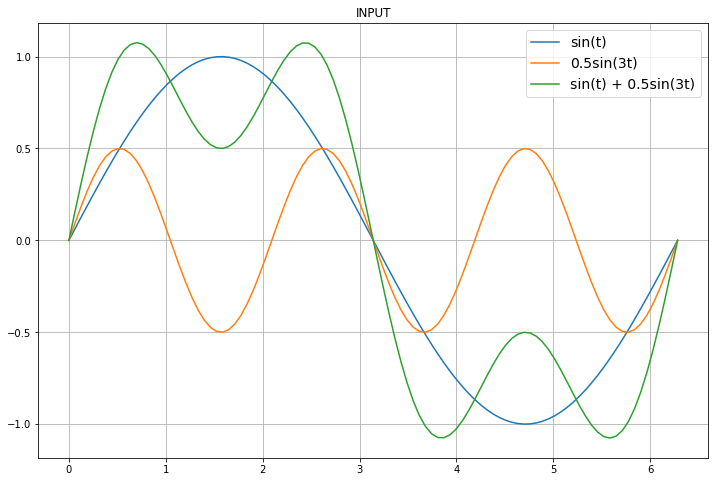

In [79]:
plt.figure(figsize=(12,8))
plt.grid()
plt.plot(t, np.sin(t),t, 0.5*np.sin(3*t), t, np.sin(t) + 0.5*np.sin(3*t) )
plt.title('INPUT')
plt.legend(['sin(t)','0.5sin(3t)', 'sin(t) + 0.5sin(3t)' ], loc='upper right', fontsize=14)

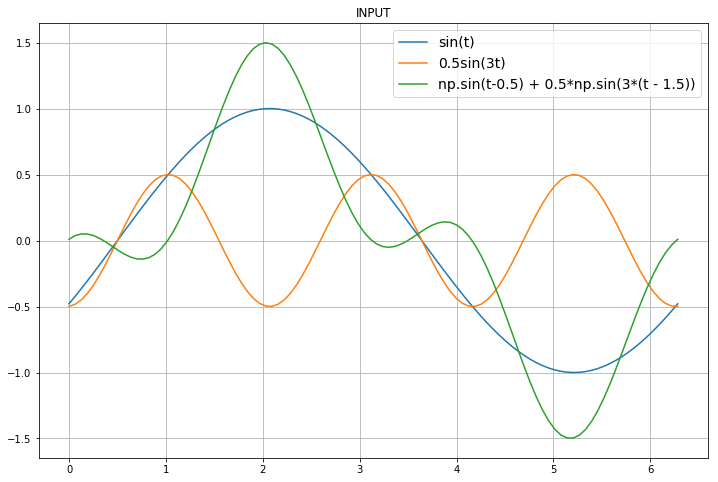

In [80]:
plt.figure(figsize=(12,8))
plt.grid()
plt.plot(t, np.sin(t-0.5),t, 0.5*np.sin(3*t - 1.5), t, np.sin(t-0.5) + 0.5*np.sin(3*(t - 1.5)) )
plt.title('INPUT')
plt.legend(['sin(t)','0.5sin(3t)', 'np.sin(t-0.5) + 0.5*np.sin(3*(t - 1.5))' ], loc='upper right', fontsize=14)

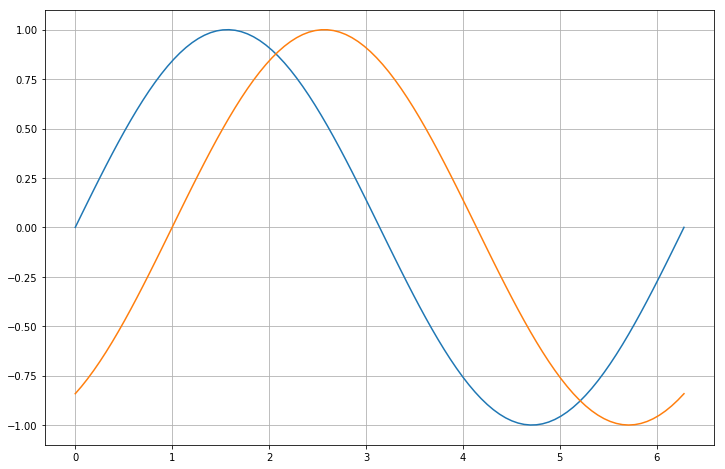

In [81]:
plt.figure(figsize=(12,8))
plt.grid()
plt.plot(t,np.sin(t), t, np.sin(t-1))

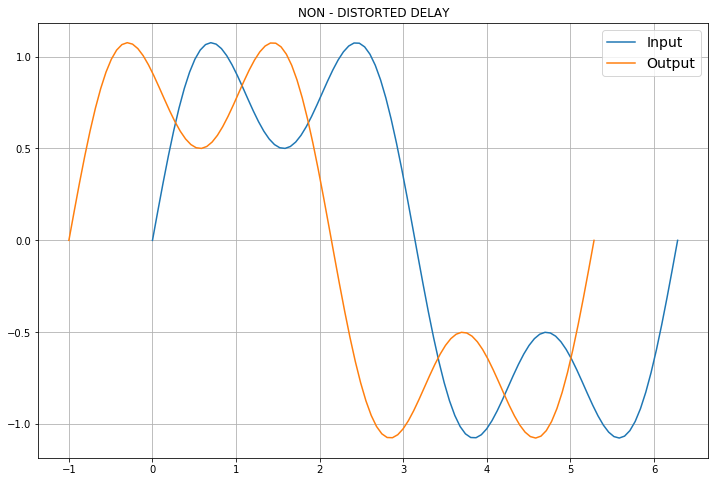

In [82]:
t = np.linspace(0,2*np.pi,100)
tt = t
plt.figure(figsize=(12,8))
plt.grid()
plt.plot(t, np.sin(t) + 0.5*np.sin(3*t),t-1, np.sin(tt) + 0.5*np.sin(3*tt) )
plt.title('NON - DISTORTED DELAY')
plt.legend(['Input', 'Output' ], loc='upper right', fontsize=14)

In [83]:
num = [2]
den = [2, 1]
sys = control.tf(num, den)
sys


   2
-------
2 s + 1

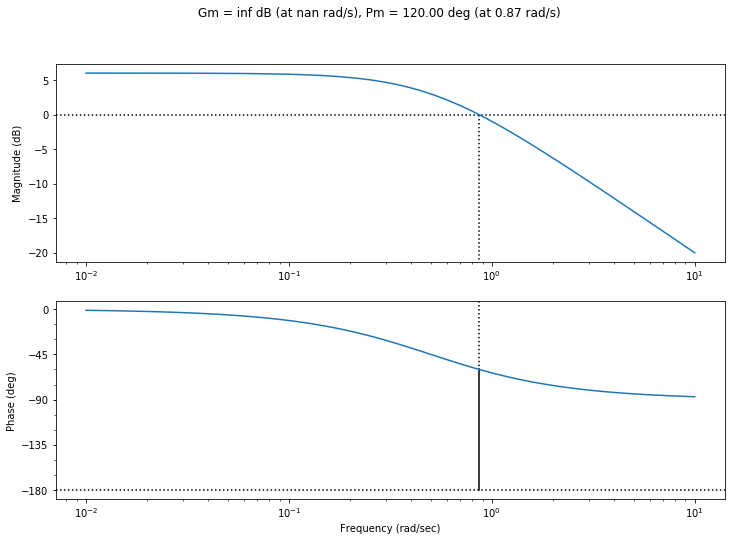

In [84]:
plt.figure(figsize=(12,8))
mag, phase, omega = control.bode_plot(sys, Hz=False, margins = True, dB = True)

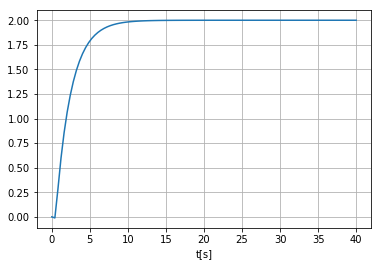

In [85]:
# Generating transfer function of Pade approx:
T_delay = 0.5
n_pade = 2
(num_pade, den_pade) = control.pade(T_delay, n_pade)
H_pade = control.tf(num_pade, den_pade)
# Generating transfer function without time delay:
num = np.array([2])
den = np.array([2, 1])
H_without_delay = control.tf(num, den)
# Generating transfer function with time delay:
H_with_delay = control.series(H_pade, H_without_delay)
# Simulation of step response:
t = np.linspace(0, 40, 100)
(t, y) = control.step_response(H_with_delay, t)
plt.plot(t, y)
plt.xlabel('t[s]')
plt.grid()
sys_delay = H_with_delay

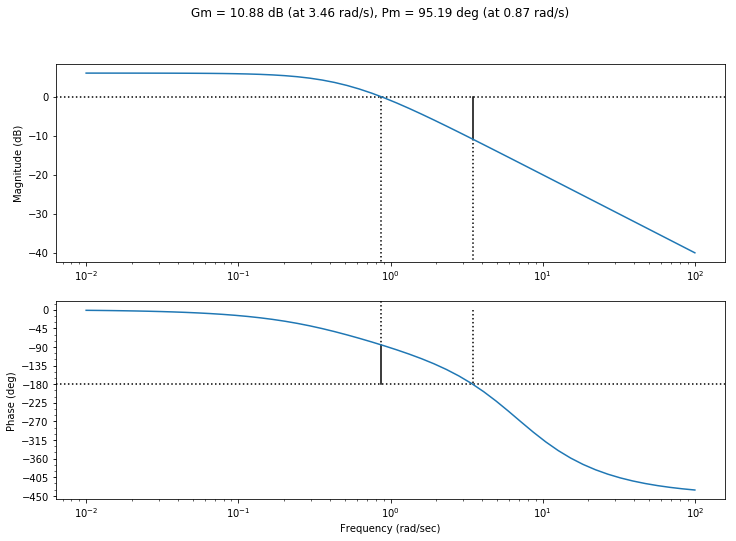

In [86]:
plt.figure(figsize=(12,8))
mag, phase, omega = control.bode_plot(sys_delay, Hz=False, margins = True, dB = True)

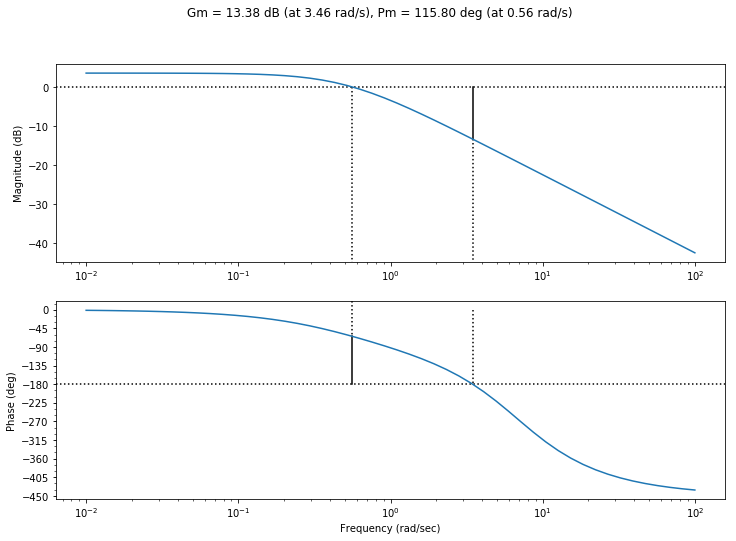

In [87]:
T_delay = 0.5
n_pade = 2
(num_pade, den_pade) = control.pade(T_delay, n_pade)
H_pade = control.tf(num_pade, den_pade)
# Generating transfer function without time delay:
num = np.array([1.5])
den = np.array([2, 1])
H_without_delay = control.tf(num, den)
# Generating transfer function with time delay:
H_with_delay = control.series(H_pade, H_without_delay)


sys_delay = H_with_delay


plt.figure(figsize=(12,8))
mag, phase, omega = control.bode_plot(sys_delay, Hz=False, margins = True, dB = True)

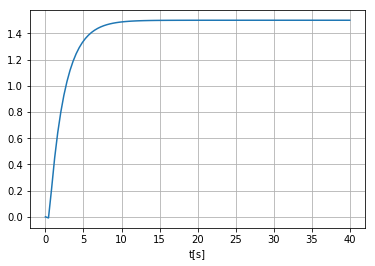

In [88]:
t = np.linspace(0, 40, 100)
(t, y) = control.step_response(H_with_delay, t)
plt.plot(t, y)
plt.xlabel('t[s]')
plt.grid()

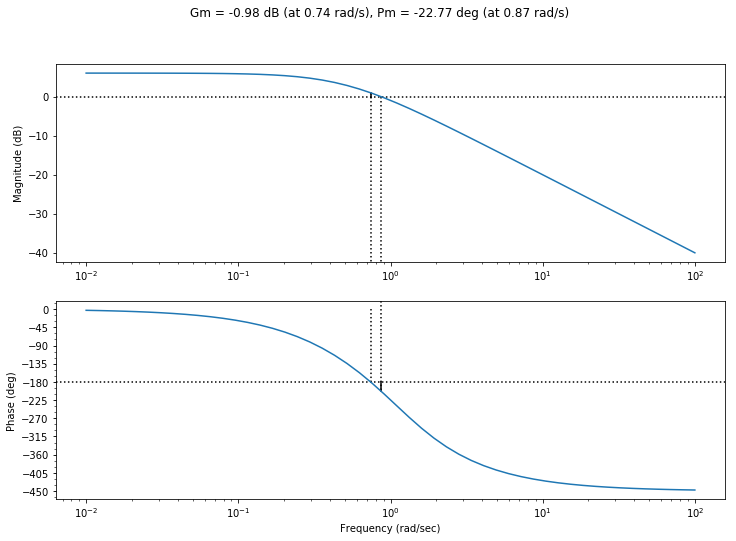

In [89]:
T_delay = 3
n_pade = 2
(num_pade, den_pade) = control.pade(T_delay, n_pade)
H_pade = control.tf(num_pade, den_pade)
# Generating transfer function without time delay:
num = np.array([2])
den = np.array([2, 1])
H_without_delay = control.tf(num, den)
# Generating transfer function with time delay:
H_with_delay = control.series(H_pade, H_without_delay)


sys_delay = H_with_delay


plt.figure(figsize=(12,8))
mag, phase, omega = control.bode_plot(sys_delay, Hz=False, margins = True, dB = True)

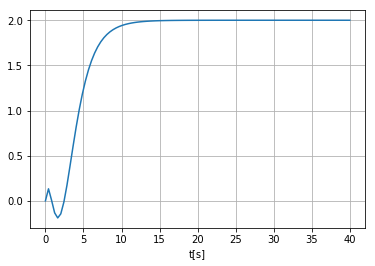

In [90]:
t = np.linspace(0, 40, 100)
(t, y) = control.step_response(H_with_delay, t)
plt.plot(t, y)
plt.xlabel('t[s]')
plt.grid()
sys_delay = H_with_delay

# NOTCH FILTER

### LOW PASS FILTER 5rad/s

In [91]:
num = [5]
den = [1, 5]
sys_L = control.tf(num, den)
sys_L


  5
-----
s + 5

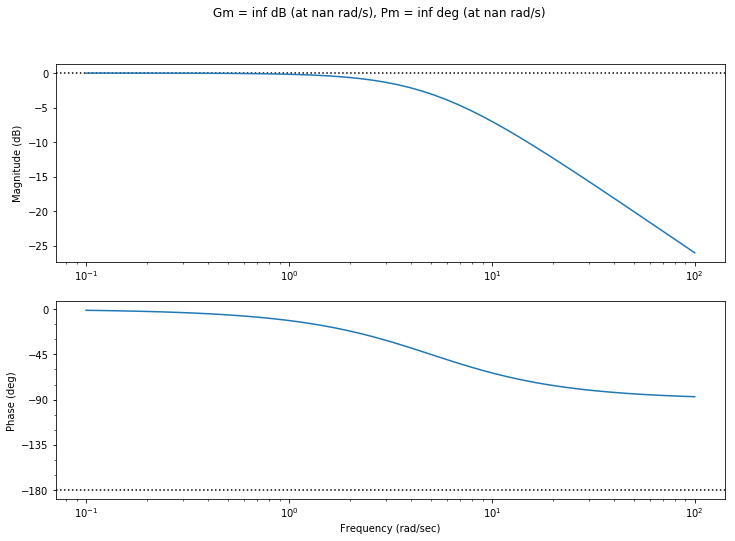

In [92]:
plt.figure(figsize=(12,8))
mag, phase, omega = control.bode_plot(sys_L, Hz=False, margins = True, dB = True)

### HIGH PASS FILTER 20rad/s

In [93]:
num = [1,0]
den = [1, 20]
sys_H = control.tf(num, den)
sys_H


  s
------
s + 20

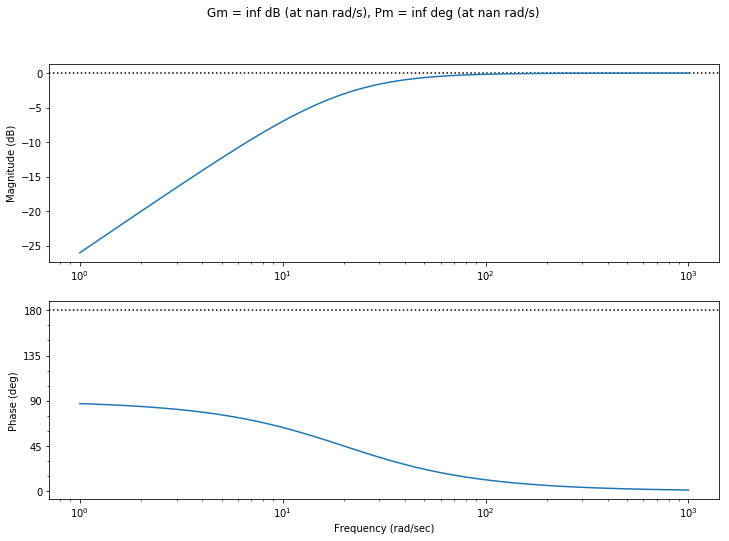

In [94]:
plt.figure(figsize=(12,8))
mag, phase, omega = control.bode_plot(sys_H, Hz=False, margins = True, dB = True)

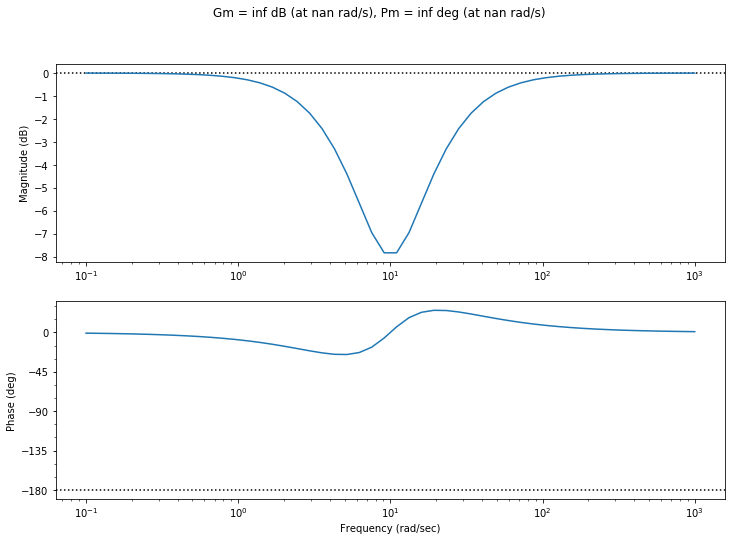

In [95]:
plt.figure(figsize=(12,8))
mag, phase, omega = control.bode_plot(sys_L+sys_H, Hz=False, margins = True, dB = True)

In [96]:
############################################################################################

In [97]:
#cutoff = 1rad/s
num = [1]
den = [1, 1]
sys_L = control.tf(num, den)
sys_L


  1
-----
s + 1

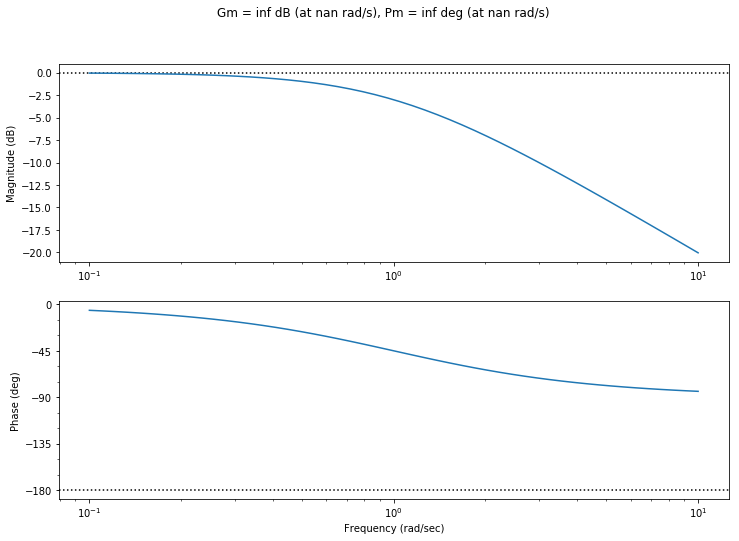

In [98]:
plt.figure(figsize=(12,8))
mag, phase, omega = control.bode_plot(sys_L, Hz=False, margins = True, dB = True)

In [99]:
#cutoff = 100rad/s
num = [1,0]
den = [1, 100]
sys_H = control.tf(num, den)
sys_H


   s
-------
s + 100

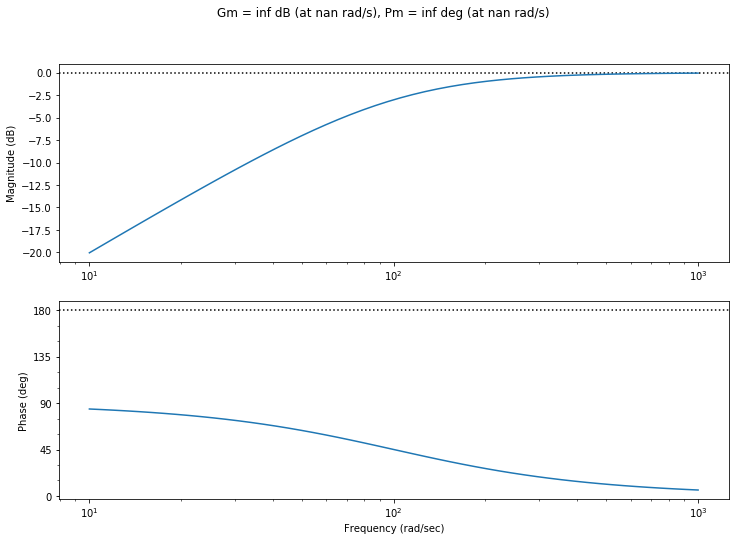

In [100]:
plt.figure(figsize=(12,8))
mag, phase, omega = control.bode_plot(sys_H, Hz=False, margins = True, dB = True)

In [101]:
num_L1 = [1]
den_L1 = [1, 1]
num_H1 = [1,0]
den_H1 = [1, 100]


sys_L1 = control.tf(num_L1, den_L1)
sys_H1 = control.tf(num_H1, den_H1)
sys_LH1 = sys_L1 + sys_H1
sys_L1 + sys_H1



 s^2 + 2 s + 100
-----------------
s^2 + 101 s + 100

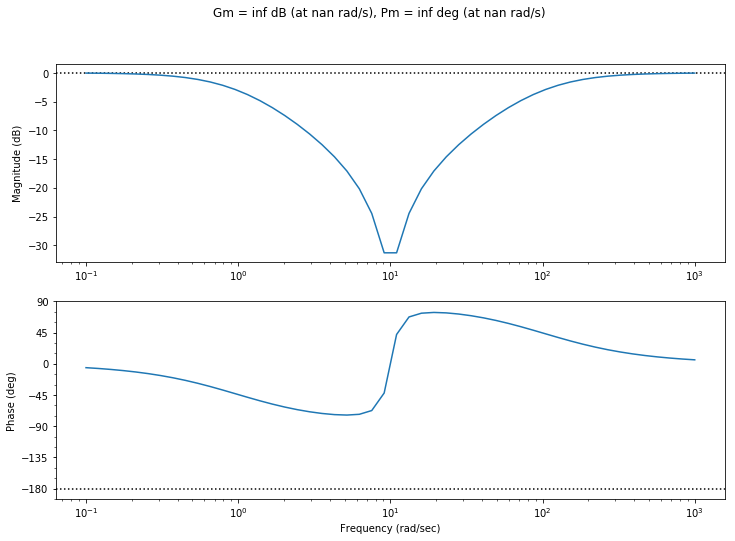

In [102]:
plt.figure(figsize=(12,8))
mag, phase, omega = control.bode_plot(sys_LH1, Hz=False, margins = True, dB = True)

### WE DO NOT HAVE CONTROL OVER THE DEPTH

In [103]:
num_L2 = [5]
den_L2 = [1, 5]
num_H2 = [1,0]
den_H2 = [1, 20]


sys_L2 = control.tf(num_L2, den_L2)
sys_H2 = control.tf(num_H2, den_H2)
sys_LH2 = sys_L2 + sys_H2
sys_L2 + sys_H2


s^2 + 10 s + 100
----------------
s^2 + 25 s + 100

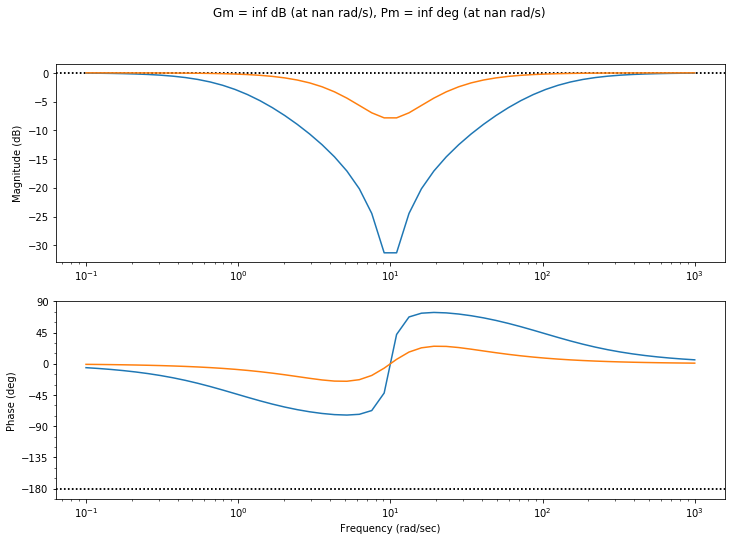

In [104]:
plt.figure(figsize=(12,8))
mag, phase, omega = control.bode_plot(sys_LH1, Hz=False, margins = True, dB = True)
mag, phase, omega = control.bode_plot(sys_LH2, Hz=False, margins = True, dB = True)
#plt.title('Low and high pass filters. Blue orginal. Orange cutoff frequency for low pass shifted from 1rad/s to 5rad/s', fontsize=18)

### WE USE STANDARD LOW PASS FILTER SECOND ORDER. WE TRY TO IMPROVVE DEPTH (INCREASE THE SLOPE OF GAIN FROM 40dB/decade to MAX

In [105]:
wn =10
zeta = 1
num = [wn*wn]
den = [1, 2*zeta*wn, wn*wn]
sys = control.tf(num, den)
sys


      100
----------------
s^2 + 20 s + 100

array([-10., -10.])

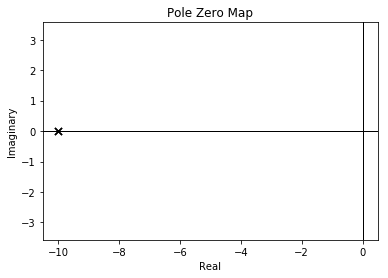

In [106]:
poles, zeros = control.pzmap(sys, Plot=True)
poles

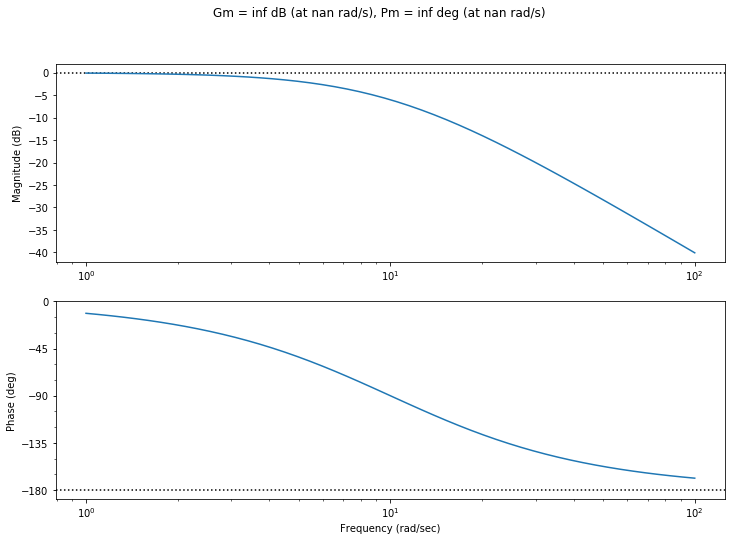

In [107]:
plt.figure(figsize=(12,8))
mag, phase, omega = control.bode_plot(sys, Hz=False, margins = True, dB = True)

### WE LOWER DAMPNING ZETA = 0.5

In [108]:
wn =10
zeta = 0.5
num = [wn*wn]
den = [1, 2*zeta*wn, wn*wn]
sys = control.tf(num, den)
sys


      100
----------------
s^2 + 10 s + 100

array([-5.+8.66025404j, -5.-8.66025404j])

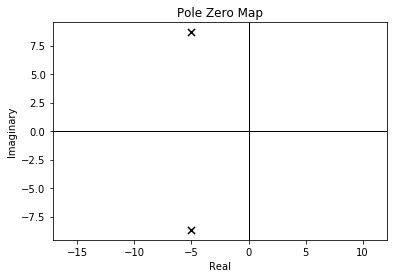

In [109]:
poles, zeros = control.pzmap(sys, Plot=True)
poles

### Sinus as input will be slightly larger at 7rad/s

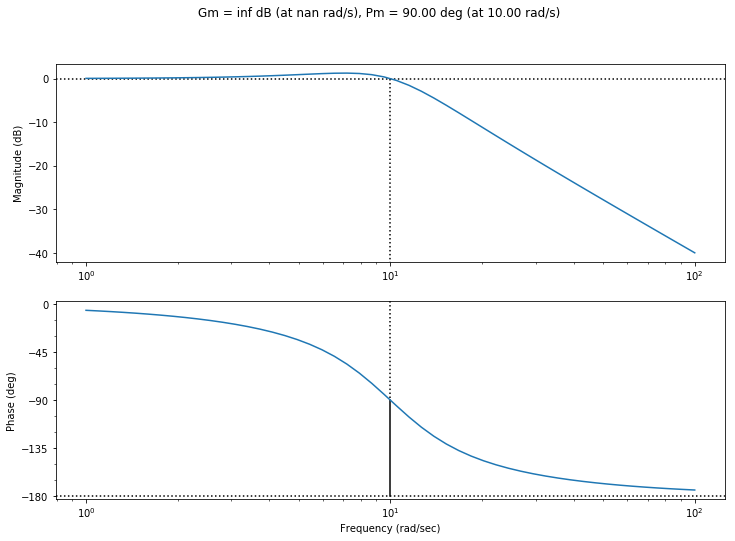

In [110]:
plt.figure(figsize=(12,8))
mag, phase, omega = control.bode_plot(sys, Hz=False, margins = True, dB = True)

### WE LOWER DAMPNING ZETA = 0.1

In [111]:
wn =10
zeta = 0.1
num = [wn*wn]
den = [1, 2*zeta*wn, wn*wn]
sys = control.tf(num, den)
sys


      100
---------------
s^2 + 2 s + 100

array([-1.+9.94987437j, -1.-9.94987437j])

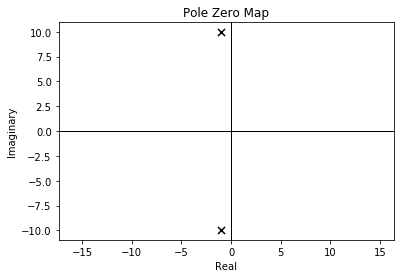

In [112]:
poles, zeros = control.pzmap(sys, Plot=True)
poles

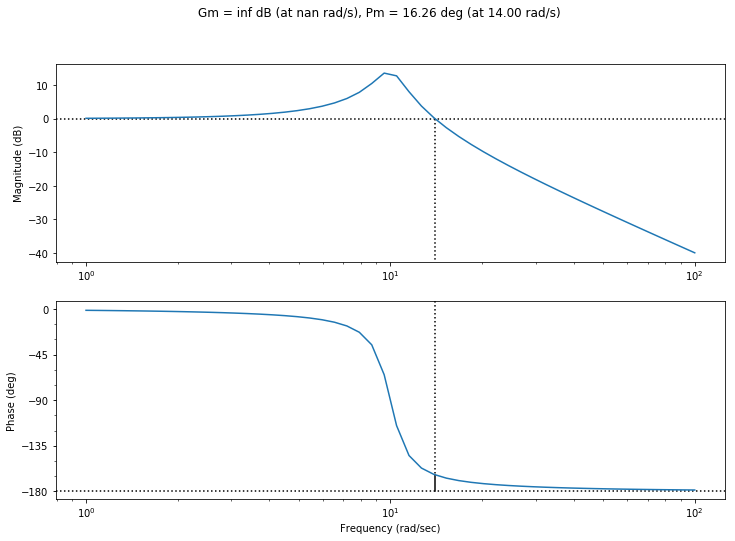

In [113]:
plt.figure(figsize=(12,8))
mag, phase, omega = control.bode_plot(sys, Hz=False, margins = True, dB = True)

### WE REMOVE DAMPNING ZETA = 0

In [114]:
wn =10
zeta = 0
num = [wn*wn]
den = [1, 2*zeta*wn, wn*wn]
sys = control.tf(num, den)
sys


   100
---------
s^2 + 100

array([-0.+10.j,  0.-10.j])

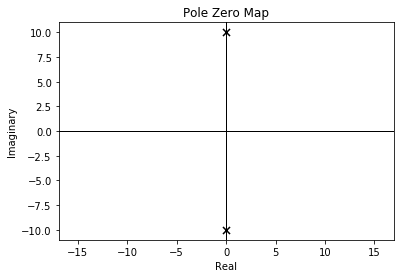

In [115]:
poles, zeros = control.pzmap(sys, Plot=True)
poles

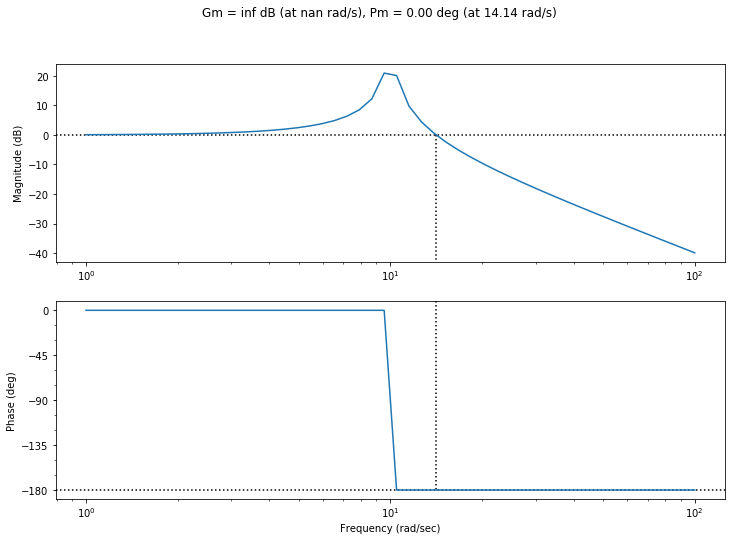

In [116]:
plt.figure(figsize=(12,8))
mag, phase, omega = control.bode_plot(sys, Hz=False, margins = True, dB = True)

### Is is a notch filter but flipped. Extremly high gain in natural frequency which normaly we wouudl like to avoid

In [117]:
wn =10
zeta = 0.0000000001
num = [wn*wn]
den = [1, 2*zeta*wn, wn*wn]
sys = control.tf(den, num)
sys


s^2 + 2e-09 s + 100
-------------------
        100

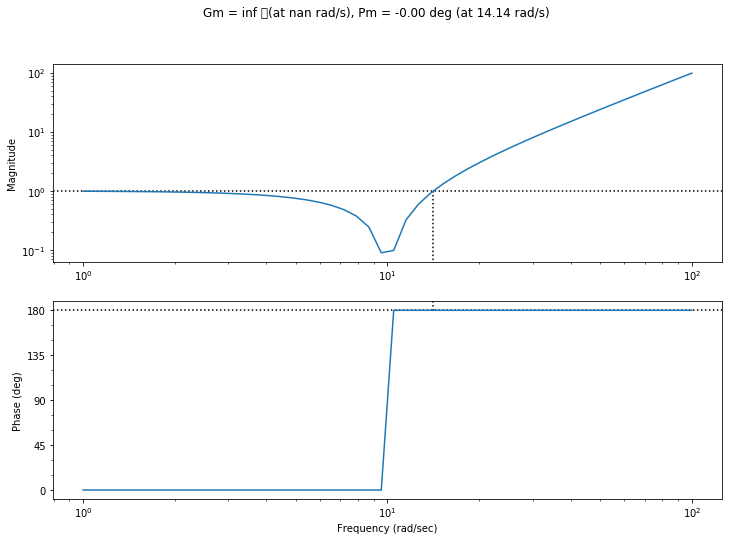

In [118]:
plt.figure(figsize=(12,8))
mag, phase, omega = control.bode_plot(sys, Hz=False, margins = True)#, dB = True)

### it is almos t perfect with thoios tranfer function but we have two problems: 1. high-freequency signals
### which are amplified by 40dB/decade since we have only two  zeros (unanswared) and
### 2. the transfer function can not be phisicaly realized because the numerator is greater then denominator
## WE FIX THESE TWO PROBLEMS BY ADDIND TWO POLES. Each pole will drag the high frequency magnintude down by 20dB/decade and flat
## our frequency response over netural frequency (crossover)

## HOW to choose poles?
## we use formula for pole which should be located below ond above natural frequency.
## pole_above = (a * wn)/(s+a* wn)
## pole_lower = (a * wn)/(s+(wn /a)) 

In [119]:
wn =10
zeta = 0.05
a = 2 # pole a time lower and higher than natural frequency
num = [wn*wn]
den = [1, 2*zeta*wn, wn*wn]
sys = control.tf(den, num)

num_pole_above = [a*wn]
den_pole_above = [1, a*wn]
pole_above = control.tf(num_pole_above, den_pole_above)

num_pole_below = [wn/a]
den_pole_below = [1, wn/a]
pole_below = control.tf(num_pole_below, den_pole_below)

notch = sys * pole_above * pole_below 

print(sys)
print(sys * pole_above)
print(sys * pole_above * pole_below)
#print(pole_above)
#print(pole_below)
print(notch)



s^2 + s + 100
-------------
     100


20 s^2 + 20 s + 2000
--------------------
    100 s + 2000


100 s^2 + 100 s + 1e+04
------------------------
100 s^2 + 2500 s + 1e+04


100 s^2 + 100 s + 1e+04
------------------------
100 s^2 + 2500 s + 1e+04



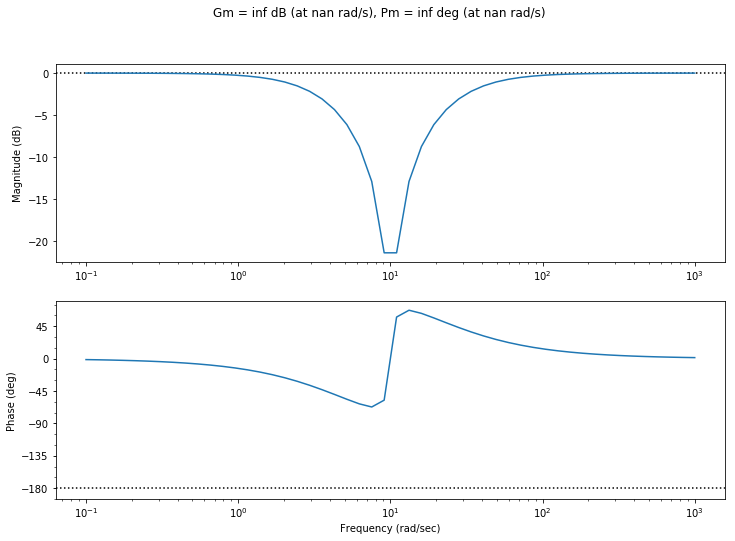

In [120]:
plt.figure(figsize=(12,8))
mag, phase, omega = control.bode_plot(notch, Hz=False, margins = True, dB = True)

## BANDWIDTH

In [121]:
#system
num = [10]
den = [1, 0.5, 1]
sys = control.tf(num, den)
sys


      10
---------------
s^2 + 0.5 s + 1

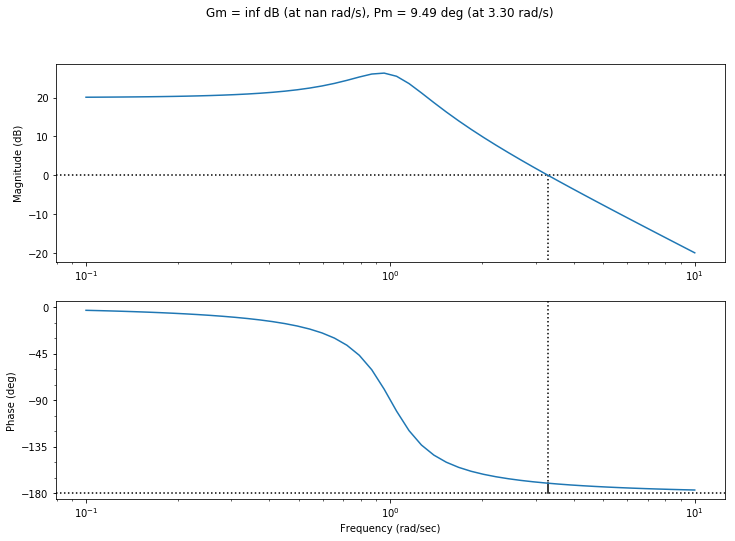

In [122]:
plt.figure(figsize=(12,8))
mag, phase, omega = control.bode_plot(sys, Hz=False, margins = True, dB = True)

#### The frequency of the input signal is below crossover (netural frequency) of the system so ampliude for signal out follows the Body plot magnitude  and in this case will be amlified. Some time delay (phase shift) can be noticed = > see Body plot for Phase change

Text(0.5, 1.0, 'Frequency of signal input below crossover frequency of the system')

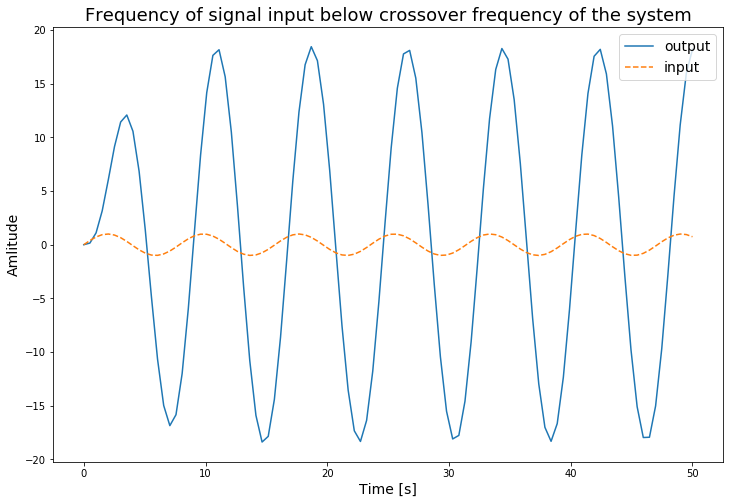

In [123]:
import control.matlab
T = np.linspace(0,50,100)

U = np.sin(1*t)



yout,t, _ = control.matlab.lsim(sys, U, T)

# Plot
plt.figure(figsize=(12,8))

plt.plot(t,yout)
plt.plot(t,U, linestyle='--') # We'll use `step` to create a staircase plot for the control actions
plt.xlabel('Time [s]', fontsize=14)
plt.ylabel('Amlitude', fontsize=14)
plt.legend(['output', 'input'], loc='upper right', fontsize=14)
plt.title('Frequency of signal input below crossover frequency of the system', fontsize=18)

#### Now (because phase compensation due to delay) we have to move crossover frequency to left so we our input signal will be weaken by the system.
## The system is now less responive and slower. Higher frequencies which "build" the stepper signal (which grows faster) are removed !!!

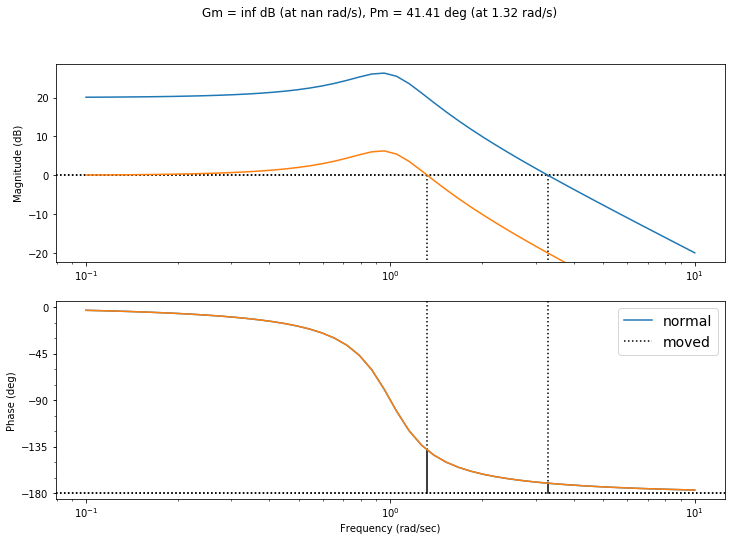

In [124]:
plt.figure(figsize=(12,8))
num_m = [1]
den_m = [1, 0.5, 1]
sys_m = control.tf(num_m, den_m)
mag, phase, omega = control.bode_plot(sys, Hz=False, margins = True, dB = True)
mag, phase, omega = control.bode_plot(sys_m, Hz=False, margins = True, dB = True)
plt.legend(['normal', 'moved'], loc='upper right', fontsize=14)

Text(0.5, 1.0, 'Frequency of signal input below crossover frequency of the system')

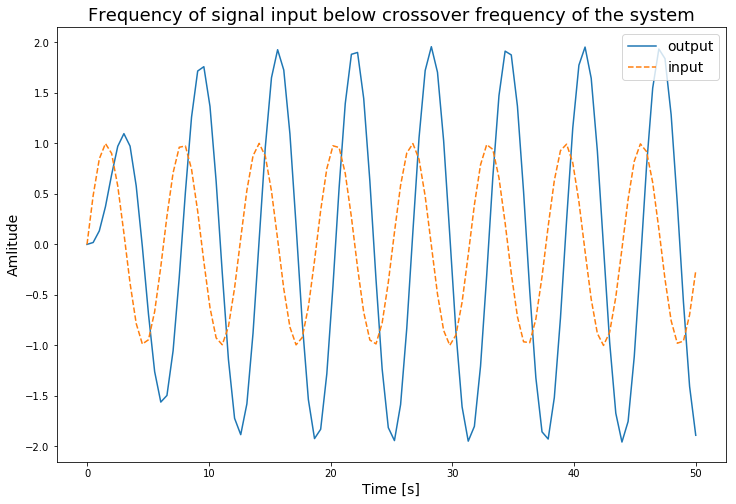

In [126]:
#import control.matlab
T = np.linspace(0,50,100)

U = np.sin(1*t)



yout,t, _ = control.matlab.lsim(sys_m, U, T)

# Plot
plt.figure(figsize=(12,8))

plt.plot(t,yout)
plt.plot(t,U, linestyle='--') # We'll use `step` to create a staircase plot for the control actions
plt.xlabel('Time [s]', fontsize=14)
plt.ylabel('Amlitude', fontsize=14)
plt.legend(['output', 'input'], loc='upper right', fontsize=14)
plt.title('Frequency of signal input below crossover frequency of the system', fontsize=18)

In [127]:
################################################################################################

In [128]:
t = np.linspace(0,10,1000)

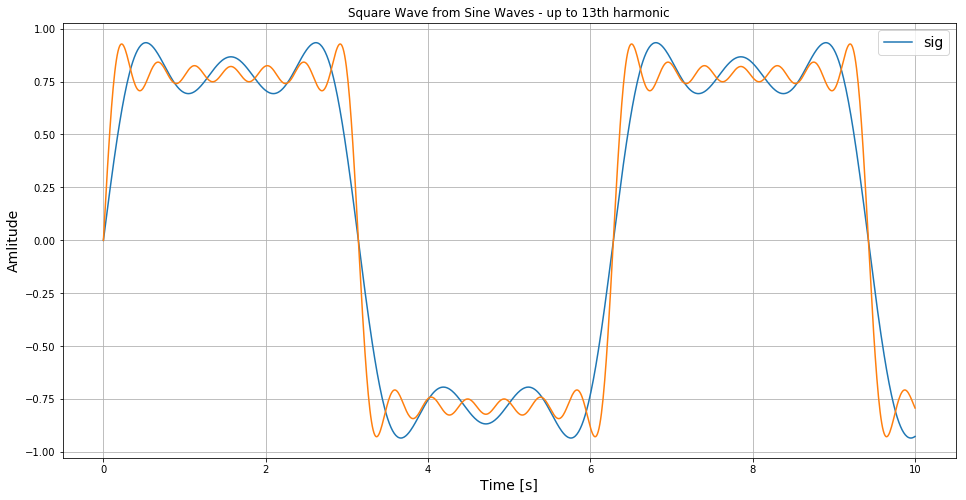

In [129]:
plt.figure(figsize=(16,8))
plt.grid()
plt.xlabel('Time [s]', fontsize=14)
plt.ylabel('Amlitude', fontsize=14)


sig = np.sin(t) + np.sin(3*t)/3 + np.sin(5*t)/5 #+ np.sin(7*t)/7 + np.sin(9*t)/9 + np.sin(11*t)/11 + np.sin(13*t)/13
sig2 = np.sin(t) + np.sin(3*t)/3 + np.sin(5*t)/5 + np.sin(7*t)/7 + np.sin(9*t)/9 + np.sin(11*t)/11 + np.sin(13*t)/13
plt.plot(t, sig, t, sig2 )
plt.title('Square Wave from Sine Waves - up to 13th harmonic')
plt.legend(['sig',], fontsize=14)
#plt.legend(['sin(t)','0.5sin(3t)', 'sin(t) + 0.5sin(3t)' ], loc='upper right', fontsize=14)

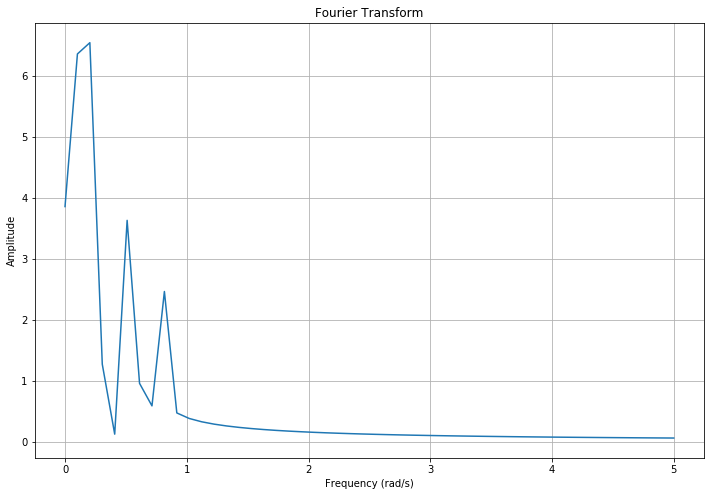

In [130]:
from scipy.fftpack import fft
plt.figure(figsize=(12,8))
N =  100 #100
T = 1.0 / 0.1

yf = fft(sig)
xf = np.linspace(0.0, 100.0/(2.0*T), N//2)



plt.title('Fourier Transform')
yfourier = 2.0/N * np.abs(yf[0:N//2])
plt.plot(xf, yfourier)
plt.grid()
plt.xlabel(r'Frequency (rad/s)')
plt.ylabel(r'Amplitude')
plt.show()

Text(0.5, 1.0, 'Square sig(sum up to 13th harmonic through design before Notch filter)')

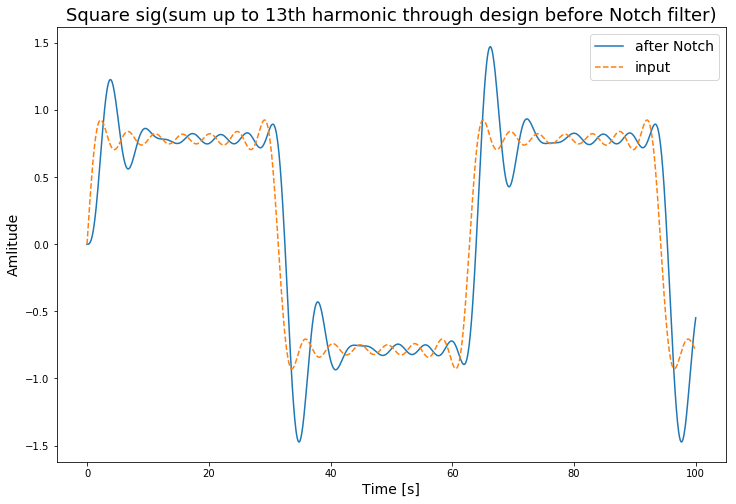

In [131]:
T = np.linspace(0,100,1000)

U = sig2



yout,t, _ = control.matlab.lsim(sys*0.1, U, T)

# Plot
plt.figure(figsize=(12,8))

plt.plot(t,yout)
plt.plot(t,U, linestyle='--') # We'll use `step` to create a staircase plot for the control actions
plt.xlabel('Time [s]', fontsize=14)
plt.ylabel('Amlitude', fontsize=14)
plt.legend(['after Notch', 'input'], loc='upper right', fontsize=14)
plt.title('Square sig(sum up to 13th harmonic through design before Notch filter)', fontsize=18)

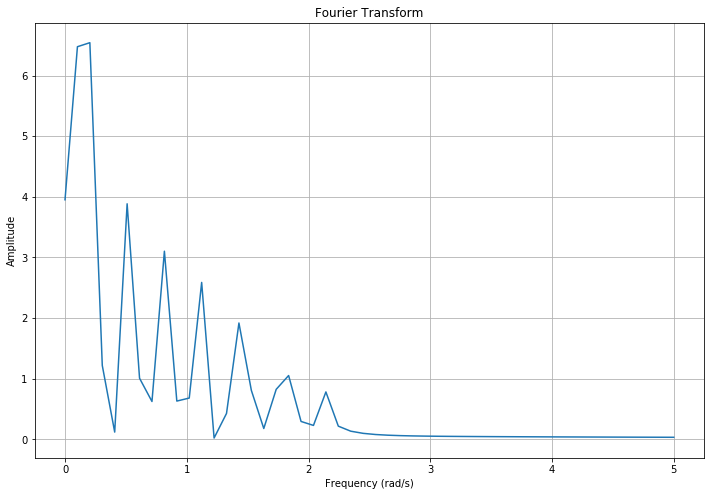

In [132]:
plt.figure(figsize=(12,8))
N =  100 #100
T = 1.0 / 0.1

yf = fft(yout)
xf = np.linspace(0.0, 100.0/(2.0*T), N//2)



plt.title('Fourier Transform')
yfourier = 2.0/N * np.abs(yf[0:N//2])
plt.plot(xf, yfourier)
plt.grid()
plt.xlabel(r'Frequency (rad/s)')
plt.ylabel(r'Amplitude')
plt.show()

## SIG THROUGHT NOTCH

In [133]:
wn =10
zeta = 0.05
a = 2 # pole a time lower and higher than natural frequency
num = [wn*wn]
den = [1, 2*zeta*wn, wn*wn]
sys = control.tf(den, num)

num_pole_above = [a*wn]
den_pole_above = [1, a*wn]
pole_above = control.tf(num_pole_above, den_pole_above)

num_pole_below = [wn/a]
den_pole_below = [1, wn/a]
pole_below = control.tf(num_pole_below, den_pole_below)

notch = sys * pole_above * pole_below 

print(sys)
print(sys * pole_above)
print(sys * pole_above * pole_below)
#print(pole_above)
#print(pole_below)
print(notch)


s^2 + s + 100
-------------
     100


20 s^2 + 20 s + 2000
--------------------
    100 s + 2000


100 s^2 + 100 s + 1e+04
------------------------
100 s^2 + 2500 s + 1e+04


100 s^2 + 100 s + 1e+04
------------------------
100 s^2 + 2500 s + 1e+04



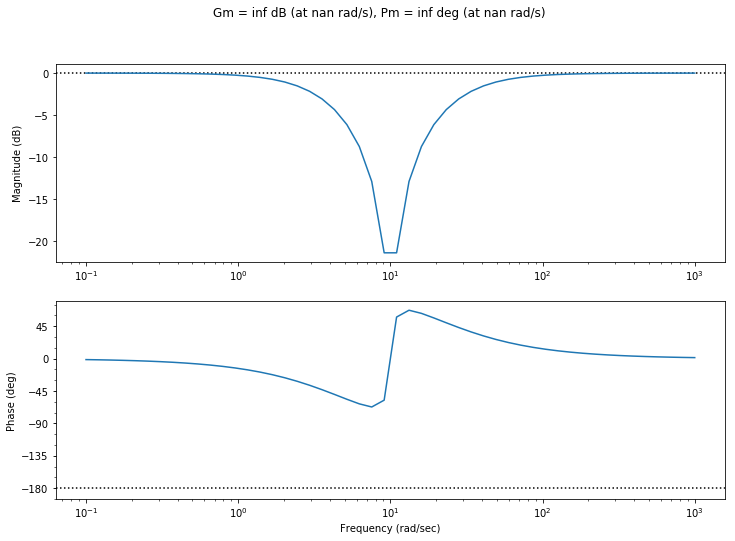

In [134]:
plt.figure(figsize=(12,8))
mag, phase, omega = control.bode_plot(notch, Hz=False, margins = True, dB = True)

In [163]:
t = np.linspace(0,1*np.pi,1000)

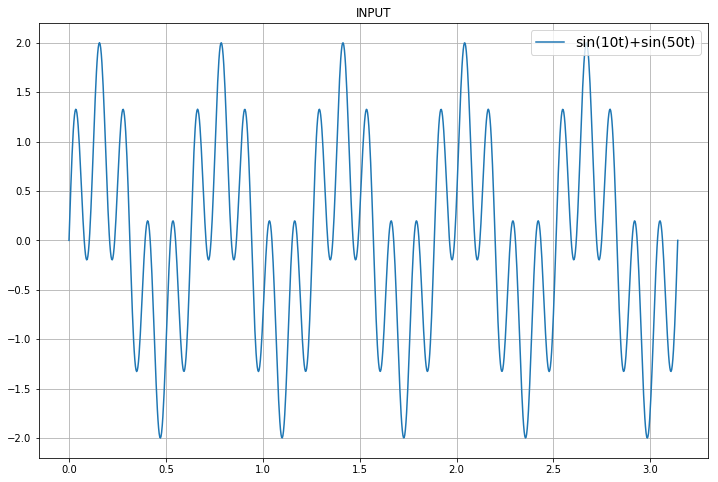

In [164]:
plt.figure(figsize=(12,8))
plt.grid()
sig3 = np.sin(10*t) + np.sin(50*t)
plt.plot(t, sig3 )
plt.title('INPUT')
plt.legend(['sin(10t)+sin(50t)' ], loc='upper right', fontsize=14)

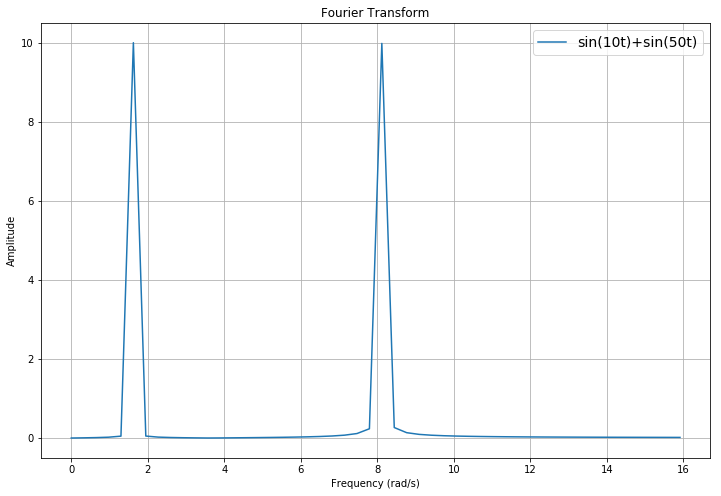

In [165]:
plt.figure(figsize=(12,8))
N =  100 #100
T = np.pi / 1.0

yf = fft(sig3)
xf = np.linspace(0.0, 100.0/(2.0*T), N//2)



plt.title('Fourier Transform')
yfourier = 2.0/N * np.abs(yf[0:N//2])
plt.plot(xf, yfourier)
plt.grid()
plt.xlabel(r'Frequency (rad/s)')
plt.ylabel(r'Amplitude')
plt.legend(['sin(10t)+sin(50t)' ], loc='upper right', fontsize=14)
plt.show()

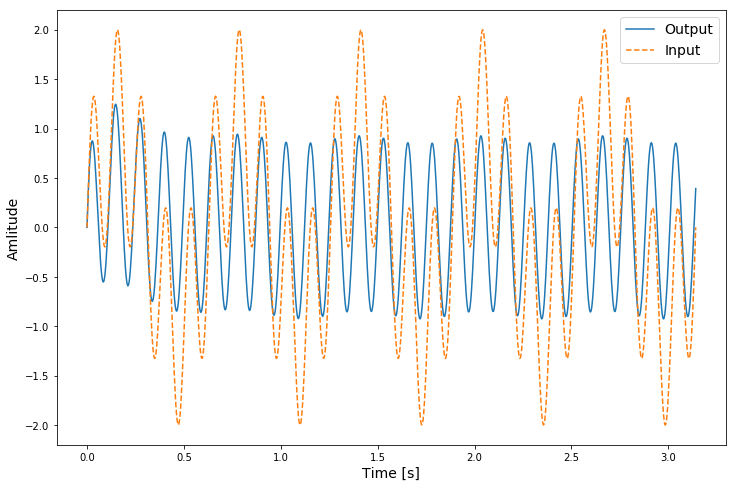

In [159]:
T = np.linspace(0,2,1000)
T= np.linspace(0,1*np.pi,1000)

U = np.sin(10*T) + np.sin (50*T)



yout,t, _ = control.matlab.lsim(notch, U, T)

# Plot
plt.figure(figsize=(12,8))

plt.plot(t,yout)
plt.plot(t,U, linestyle='--') # We'll use `step` to create a staircase plot for the control actions
plt.xlabel('Time [s]', fontsize=14)
plt.ylabel('Amlitude', fontsize=14)
plt.legend(['Output', 'Input'], loc='upper right', fontsize=14)

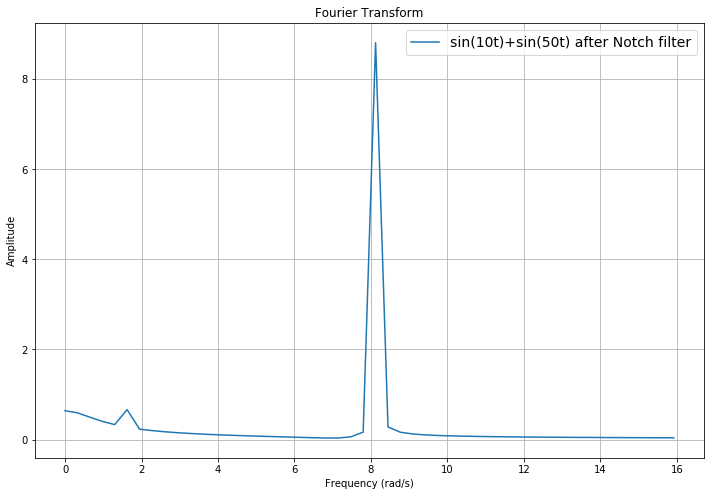

In [166]:
plt.figure(figsize=(12,8))
N =  100 #100
T = np.pi / 1.0

yf = fft(yout)
xf = np.linspace(0.0, 100.0/(2.0*T), N//2)



plt.title('Fourier Transform')
yfourier = 2.0/N * np.abs(yf[0:N//2])
plt.plot(xf, yfourier)
plt.grid()
plt.xlabel(r'Frequency (rad/s)')
plt.ylabel(r'Amplitude')
plt.legend(['sin(10t)+sin(50t) after Notch filter' ], loc='upper right', fontsize=14)
plt.show()

# THE END

In [ ]:
####################################################################################################################

In [ ]:
#####################################################################################################################

In [ ]:
plt.figure(figsize=(12,8))
mag, phase, omega = control.nyquist_plot([sys])
plt.legend(['close loop'], loc='upper right', fontsize=14)

In [ ]:
feed_ctrl = control.feedback(sys,1)

In [ ]:
plt.figure(figsize=(12,8))
mag, phase, omega = control.bode_plot(feed_ctrl, Hz=False)

In [ ]:
plt.figure(figsize=(12,8))
mag, phase, omega = control.nyquist_plot([sys + 1])
plt.legend(['close loop'], loc='upper right', fontsize=14)

## Controler

In [ ]:

num = [50]
den = [3,9,30,40]
sys = control.tf(num, den)
sys

In [ ]:
plt.figure(figsize=(12,8))
mag, phase, omega = control.bode_plot(sys, Hz=False, margins = True)

In [ ]:
num_ctrl = [1]
den_ctrl = [1, 0]
ctrl = control.tf(num_ctrl, den_ctrl)
ctrl

In [ ]:
feed_ctrl = control.feedback(sys*ctrl,1)

In [ ]:
plt.figure(figsize=(12,8))
mag, phase, omega = control.bode_plot(feed_ctrl, Hz=False)

In [ ]:
J = 0.01
b = 0.1
K = 0.01
R = 1
L = 0.5
P_motor = control.tf([K],[0.005,0.06,0.1001])
P_motor


In [ ]:
plt.figure(figsize=(12,8))
mag, phase, omega = control.bode_plot(P_motor, Hz=False)

In [ ]:
num_ctrl = [1*45,1*45]
den_ctrl = [1, 0.01]
ctrl = control.tf(num_ctrl, den_ctrl)
ctrl

In [ ]:
plt.figure(figsize=(12,8))
mag, phase, omega = control.bode_plot(ctrl, Hz=False)

In [ ]:
feed_ctrl = control.feedback(P_motor*ctrl,1)

In [ ]:
plt.figure(figsize=(12,8))
mag, phase, omega = control.bode_plot(feed_ctrl, Hz=False)

In [ ]:
plt.figure(figsize=(12,8))
mag, phase, omega = control.bode_plot(P_motor*ctrl, Hz=False)

In [ ]:
plt.figure(figsize=(12,8))
mag, phase, omega = control.bode_plot(feed_ctrl, Hz=False, margins = True)

In [ ]:
plt.figure(figsize=(12,8))
mag, phase, omega = control.bode_plot(P_motor*ctrl, Hz=False, margins = True)

In [ ]:
# Generate a step response
T = np.linspace(0,30,100)
t, yout = control.step_response(P_motor*ctrl,T)

# Plot
plt.figure(figsize=(12,8))


plt.plot(t,yout)
plt.xlabel('Time [s]', fontsize=18)
plt.ylabel('Output', fontsize=18)
plt.legend(['step response'], loc='upper right', fontsize=14)

In [ ]:
# Generate a step response
T = np.linspace(0,30,100)
t, yout = control.step_response(feed_ctrl,T)

# Plot
plt.figure(figsize=(12,8))


plt.plot(t,yout)
plt.xlabel('Time [s]', fontsize=18)
plt.ylabel('Output', fontsize=18)
plt.legend(['step response'], loc='upper right', fontsize=14)